# Comparison of unsmoothed and expert products

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert,load_swot_l2_unsmoothed  

## 1. Inputs


In [182]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_013_344_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_344_mascarene_test.nc'
if True:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_023_344_mascarene_test2.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_023_344_mascarene_test2.nc'

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 500.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.25
DETREND = 'constant'
# ── Box size ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX, LON_MIN, LON_MAX = -60.0,60.0, 0.0, 360.0
BOX_DEG = 10.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)



In [183]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset."""
    if not all_segments:
        raise ValueError('No segments to pack.')
    psd = np.stack([s.psd for s in all_segments], axis=0)
    return xr.Dataset(
        data_vars=dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': 'Along-track SSH(A) PSD',
                  'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments],
                      {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments],
                     {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments],
                     {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments],
                      {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            #granule=(['segment'], [s._granule for s in all_segments]),
            #year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
            #      {'long_name': 'Year of the source SWOT sub-directory'}),
            #month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
            #       {'long_name': 'Month of the source SWOT sub-directory'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        ),
    )


def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [4]:
from __future__ import annotations

import dataclasses
from typing import Optional, Sequence

import numpy as np
from scipy import signal
from pathlib import Path
try:
    import xarray as xr
except ImportError:  # xarray is optional - only needed for the file loader
    xr = None


EARTH_RADIUS_KM = 6371.0088


# --------------------------------------------------------------------------- #
# Data containers
# --------------------------------------------------------------------------- #

@dataclasses.dataclass
class SegmentSpectrum:
    """Spectral estimate and metadata for a single along-track segment."""

    swath: str                  # "left" or "right"
    segment_index: int          # index of this segment along the pass
    wavenumber: np.ndarray      # cycles per km (1-D, length = nperseg//2+1)
    psd: np.ndarray             # PSD in (SSH units)^2 / (cycles/km), 1-D
    n_pixels_used: int          # number of cross-track pixels averaged
    lat_mean: float
    lat_min: float
    lat_max: float
    lon_mean: float
    along_track_distance_start_km: float
    along_track_distance_end_km: float
    valid_fraction: float       # fraction of non-NaN samples before fill
    gap_filled: bool            # whether interior NaNs were interpolated
    month: int                  # month associated with swath


@dataclasses.dataclass
class PassSpectrumResult:
    """Full result for one pass: per-segment spectra + mean spectrum per swath."""

    swath: str
    wavenumber: np.ndarray              # common wavenumber axis (cycles/km)
    mean_psd: np.ndarray                # pass-mean PSD, averaged over segments
    n_segments_used: int
    n_segments_total: int
    segments: list  # list[SegmentSpectrum]
    month: int      # month associated with swath

    def segment_latitudes(self) -> np.ndarray:
        """Convenience: array of mean latitude for each retained segment."""
        return np.array([s.lat_mean for s in self.segments])


# --------------------------------------------------------------------------- #
# Loading helper (optional convenience; not required if you already have
# numpy arrays of ssha/lat/lon/cross_track_distance)
# --------------------------------------------------------------------------- #

def load_swot_l2(filepath: str, ssh_var: str = "ssha_karin_2", hret: bool = True):
    """
    Load the variables needed for spectral analysis from a SWOT L2 LR
    Basic netCDF granule.

    Parameters
    ----------
    filepath : str
        Path to a SWOT_L2_LR_SSH_*_Basic*.nc file.
    ssh_var : str
        Name of the SSH(A) variable to extract. For the Expert product
        this is typically "ssha_karin_2" (KaRIn SSHA with the
        recommended editing/corrections already applied) or
        "ssh_karin_2". Use "ssha_karin" / "ssh_karin" for the
        non-default variants if preferred.
    hret : bool
        Include or exclude coherent internal tides from HRET. 
        Default is True to include internal tide (i.e. adding it to SWOT products).
        It only applies if ssh_var is ssha.
    Returns
    -------
    dict with keys:
        ssha : (num_lines, num_pixels) float array, NaN where invalid
               or flagged by quality flags / land.
        latitude, longitude : (num_lines, num_pixels) float arrays
        cross_track_distance : (num_pixels,) or (num_lines, num_pixels)
               float array, negative on the left swath, positive on the
               right swath, NaN/0 over the nadir gap.
    """
    if xr is None:
        raise ImportError("xarray is required for load_swot_l2_basic(); "
                           "install it, or build the input arrays yourself "
                           "and call compute_pass_spectra() directly.")

    ds = xr.open_dataset(filepath)

    ssha = ds[ssh_var]+ds['height_cor_xover']#.values.astype(float)
    if ssh_var=='ssha_karin_2':
        if hret==True:
            ssha = ssha + ds['internal_tide_hret']
    else:
        pass
    ssha = ssha.values.astype(float)
    # Mask out flagged data using the associated quality flag, if present.
    qual_var = ssh_var.replace("ssha", "ssha").replace("ssh_karin_2", "ssh_karin_2")
    for cand in (f"{ssh_var}_qual", "ssha_karin_2_qual", "ssh_karin_2_qual"):
        if cand in ds.variables:
            qual = ds[cand].values
            ssha = np.where(qual == 0, ssha, np.nan)
            break

    lat = ds["latitude"].values.astype(float)
    lon = ds["longitude"].values.astype(float)

    if "cross_track_distance" in ds.variables:
        xtrack = ds["cross_track_distance"].values.astype(float)
    else:
        raise KeyError("cross_track_distance variable not found; needed to "
                        "separate left/right swaths and exclude the nadir gap.")

    ds.close()
    return {
        "ssha": ssha,
        "latitude": lat,
        "longitude": lon,
        "cross_track_distance": xtrack,
    }


def load_swot_l2_expert(filepath, ssh_var='ssha_karin_2', HRET=True, swh_var=False):
    # NO type annotations — avoids Python 3.14 PEP 649 __annotate__ capture bug
    ds = xr.open_dataset(filepath)
    if HRET:
        #ssha   = np.array(ds[ssh_var] + ds['height_cor_xover'] + ds['internal_tide_hret'], dtype='float64')
        ssha = (ds[ssh_var] + ds['height_cor_xover'] + ds['internal_tide_hret']).values
        #ssha = (ds[ssh_var] + ds['height_cor_xover']+ ds['internal_tide_hret']).values#.copy()
    else:
        ssha   = np.array(ds[ssh_var] + ds['height_cor_xover'], dtype='float64')
        #ssha = (ds[ssh_var] + ds['height_cor_xover']).values#.copy()
    #ssha = ssha.astype('float64')   # string dtype, no builtins involved

    for qual_name in (f'{ssh_var}_qual', 'ssha_karin_2_qual', 'ssh_karin_2_qual'):
        if qual_name in ds.variables:
            ssha = np.where(np.array(ds[qual_name]) == 0, ssha, np.nan)
            #ssha = np.where(ds[qual_name].values == 0, ssha, np.nan)
            break
    for scf in ('ancillary_surface_classification_flag', 'surface_classification_flag'):
        if scf in ds.variables:
            ssha = np.where(np.array(ds[scf]) == 0, ssha, np.nan)
            break
    if 'surface_type' in ds.variables:
        ssha = np.where(np.array(ds['surface_type']) == 0, ssha, np.nan)
    lat = ds['latitude'].values
    lon = ds['longitude'].values
    xtrack = ds['cross_track_distance'].values
    
    if swh_var:
        swh = np.where(np.array(ds['swh_karin_qual'])==0, np.array(ds['swh_karin']), np.nan)
        ssha = np.where(swh<=5,ssha,np.nan)
        
    ds.close()
    return {'ssha': ssha, 'latitude': lat, 'longitude': lon,
                'cross_track_distance': xtrack}
        

def load_swot_l2_unsmoothed(filepath, ssh_var='ssha_karin_2', HRET=True):
    """
    Load the variables needed for spectral analysis from a SWOT L2 LR
    Unsmoothed granule. Unlike the Expert product, Unsmoothed data is
    split across two netCDF groups ('left' and 'right'); this function
    merges them into the same flat (num_lines, num_pixels) layout used
    by load_swot_l2_expert, so downstream code (compute_pass_spectra,
    split_left_right_swaths) needs no changes.
    """
    def _load_group(group_name, flip):
        ds = xr.open_dataset(filepath, group=group_name)

        if HRET:
            ssha = (ds[ssh_var] + ds['height_cor_xover'] + ds['internal_tide_hret']).values
        else:
            ssha = np.array(ds[ssh_var] + ds['height_cor_xover'])

        for qual_name in (f'{ssh_var}_qual', 'ssha_karin_2_qual', 'ssh_karin_2_qual'):
            if qual_name in ds.variables:
                ssha = np.where(np.array(ds[qual_name]) == 0, ssha, np.nan)
                break
        for scf in ('ancillary_surface_classification_flag', 'surface_classification_flag'):
            if scf in ds.variables:
                ssha = np.where(np.array(ds[scf]) == 0, ssha, np.nan)
                break
        if 'surface_type' in ds.variables:
            ssha = np.where(np.array(ds['surface_type']) == 0, ssha, np.nan)

        lat = ds['latitude'].values
        lon = ds['longitude'].values
        xtrack = np.array(ds['cross_track_distance'], dtype='float64')
        # sign convention: negative = left swath, positive = right swath,
        # matching what split_left_right_swaths() expects downstream
        sign = -1.0 if group_name == 'left' else 1.0
        xtrack = sign * np.abs(xtrack)

        ds.close()

        if flip:
            ssha = ssha[:, ::-1]
            lat = lat[:, ::-1]
            lon = lon[:, ::-1]
            xtrack = xtrack[:, ::-1] if xtrack.ndim == 2 else xtrack[::-1]

        return ssha, lat, lon, xtrack

    # left group's cross-track index runs right-to-left -> flip it so both
    # groups increase with distance from nadir in the same direction
    ssha_l, lat_l, lon_l, xtrack_l = _load_group('left', flip=True)
    ssha_r, lat_r, lon_r, xtrack_r = _load_group('right', flip=False)

    ssha = np.concatenate([ssha_l, ssha_r], axis=1)
    lat = np.concatenate([lat_l, lat_r], axis=1)
    lon = np.concatenate([lon_l, lon_r], axis=1)
    xtrack = np.concatenate([xtrack_l, xtrack_r], axis=1) if xtrack_l.ndim == 2 \
        else np.concatenate([xtrack_l, xtrack_r])

    return {'ssha': ssha, 'latitude': lat, 'longitude': lon,
            'cross_track_distance': xtrack}
# --------------------------------------------------------------------------- #
# Geometry helpers
# --------------------------------------------------------------------------- #

def _haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.minimum(1.0, a)))


def along_track_distance_km(lat: np.ndarray, lon: np.ndarray,
                             axis: int = 0) -> np.ndarray:
    """
    Cumulative along-track distance (km) computed along `axis`, using a
    representative cross-track index (median pixel column) so that a
    single along-track distance axis can be shared by all pixel columns
    of a swath.

    lat, lon : (num_lines, num_pixels) arrays (NaNs allowed away from the
               reference column).
    """
    if lat.ndim == 1:
        ref_lat, ref_lon = lat, lon
    else:
        ref_col = lat.shape[1] // 2
        ref_lat = lat[:, ref_col]
        ref_lon = lon[:, ref_col]
        # fall back to nearest valid column if the reference is empty
        if np.all(np.isnan(ref_lat)):
            valid_cols = [c for c in range(lat.shape[1])
                          if not np.all(np.isnan(lat[:, c]))]
            if not valid_cols:
                raise ValueError("No valid latitude data found to build "
                                  "along-track distance axis.")
            ref_col = valid_cols[len(valid_cols) // 2]
            ref_lat = lat[:, ref_col]
            ref_lon = lon[:, ref_col]

    # interpolate over any internal NaNs in the reference track so the
    # distance axis itself is always well defined
    ref_lat = _interp_nan_1d(ref_lat)
    ref_lon = _interp_nan_1d(ref_lon)

    d = np.zeros_like(ref_lat)
    d[1:] = _haversine_km(ref_lat[:-1], ref_lon[:-1], ref_lat[1:], ref_lon[1:])
    return np.cumsum(d)


def _interp_nan_1d(x: np.ndarray) -> np.ndarray:
    """Linearly interpolate interior NaNs in a 1-D array; edge NaNs are
    filled with the nearest valid value (no extrapolation of slope)."""
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    idx = np.arange(n)
    good = ~np.isnan(x)
    if good.sum() == 0:
        return x
    if good.sum() < n:
        x[~good] = np.interp(idx[~good], idx[good], x[good])
    return x


# --------------------------------------------------------------------------- #
# Swath splitting
# --------------------------------------------------------------------------- #

def split_left_right_swaths(cross_track_distance: np.ndarray, remove_edges = None):
    """
    Return boolean column masks (left_mask, right_mask) over the
    cross-track (pixel) dimension, identifying which pixel columns
    belong to the left swath (negative cross-track distance), the right
    swath (positive), and implicitly excluding the nadir-gap columns
    (NaN or exactly 0 cross-track distance), which fall into neither
    mask.

    cross_track_distance may be 1-D (num_pixels,) or 2-D
    (num_lines, num_pixels); if 2-D, the per-pixel sign is taken from
    the median across lines (the swath geometry is essentially constant
    along track).
    """
    xt = np.asarray(cross_track_distance, dtype=float)
    if xt.ndim == 2:
        xt = np.nanmedian(xt, axis=0)
    
    if remove_edges is not None:
        xt_l = xt[xt > 0]
        xt_r = xt[xt < 0]
        xt0_l = np.nanmedian(xt_l)
        xt0_r = np.nanmedian(xt_r)
        swath_width_l = xt_l.max() - xt_l.min()
        swath_width_r = xt_r.max() - xt_r.min()
        left_mask  = (xt > xt0_l - (swath_width_l - remove_edges)//2) & (xt < xt0_l + (swath_width_l - remove_edges)//2)
        right_mask = (xt > xt0_r - (swath_width_r - remove_edges)//2) & (xt < xt0_r + (swath_width_r - remove_edges)//2)
    else :
        left_mask = xt > 0
        right_mask = xt < 0    
    return left_mask, right_mask


# --------------------------------------------------------------------------- #
# Core spectral computation
# --------------------------------------------------------------------------- #

def _segment_bounds(distance_km: np.ndarray, segment_length_km: float,
                     overlap: float = 0.0):
    """Yield (i_start, i_end) index pairs splitting `distance_km` into
    along-track segments of length `segment_length_km`, with optional
    fractional overlap (0 <= overlap < 1).

    A final segment is always anchored to the exact end of the track (in
    addition to the regularly-stepped segments), so that up to
    `segment_length_km` of data at the tail of every pass is not silently
    dropped. Without this, since essentially every SWOT granule starts its
    along-track distance count at very nearly the same orbital turning
    latitude, the always-discarded tail lands at the same absolute
    latitude for every file -- which shows up as a solid, uncovered
    latitude band once results are aggregated across many
    passes/granules, growing wider as segment_length_km increases.
    """
    if (0.0 <= overlap < 1.0):
        step_km = segment_length_km * (1.0 - overlap)
    else:
        raise ValueError("overlap must be in [0, 1).")
    total = distance_km[-1]
    starts_km = list(np.arange(distance_km[0], total - segment_length_km + 1e-9, step_km))
    if len(starts_km) == 0:
        # pass shorter than one segment: use whole pass as a single segment
        starts_km = [distance_km[0]]

    # Anchor one final segment to the literal end of the track, even if it
    # overlaps the previous segment more than the nominal step -- this
    # guarantees full start-to-end coverage regardless of segment_length_km.
    last_start_needed = total - segment_length_km
    if last_start_needed > starts_km[-1] + 1e-9:
        starts_km.append(last_start_needed)

    bounds = []
    seen_i1 = set()
    for s_km in starts_km:
        e_km = s_km + segment_length_km
        i0 = int(np.searchsorted(distance_km, s_km, side="left"))
        i1 = int(np.searchsorted(distance_km, e_km, side="right"))
        if i1 - i0 < 8:  # need a minimum number of samples to FFT meaningfully
            continue
        if i1 in seen_i1:  # avoid a near-duplicate segment when already reaching the end
            continue
        seen_i1.add(i1)
        bounds.append((i0, i1))
    return bounds


def _segment_bounds_at_latitudes(distance_km: np.ndarray, lat: np.ndarray,
                                  target_lats: Sequence[float],
                                  segment_length_km: float):
    """Build along-track segment index bounds centered on a set of target
    latitudes, instead of on a regular along-track grid (cf.
    `_segment_bounds`).

    For each value in `target_lats`, the nearest along-track sample (by
    `lat`, the reference-column latitude used to build `distance_km`) is
    located, and a segment of length `segment_length_km` is centered on
    that sample's along-track distance. This lets one product's segments
    (e.g. Unsmoothed) be anchored to another product's segment centroids
    (e.g. Expert), so both products' spectra are computed for segments
    sharing the same central latitude, rather than each product
    independently choosing its own segment boundaries (which -- since the
    two products have different native samplings and are processed
    independently -- otherwise end up centered at slightly different
    latitudes even when nominally covering "the same" stretch of track).

    A target latitude whose centered segment would run off either end of
    the track, or that ends up with fewer than 8 samples, is silently
    skipped (dropped, not substituted with the nearest valid segment) so
    that the returned bounds stay in one-to-one correspondence with (a
    subset of) `target_lats`.
    """
    lat = _interp_nan_1d(np.asarray(lat, dtype=float))
    half_len = segment_length_km / 2.0
    track_start, track_end = distance_km[0], distance_km[-1]

    bounds = []
    for target_lat in target_lats:
        center_idx = int(np.argmin(np.abs(lat - target_lat)))
        center_km = distance_km[center_idx]
        s_km = center_km - half_len
        e_km = center_km + half_len
        if s_km < track_start or e_km > track_end:
            continue  # segment centered here would run off the track
        i0 = int(np.searchsorted(distance_km, s_km, side="left"))
        i1 = int(np.searchsorted(distance_km, e_km, side="right"))
        if i1 - i0 < 8:  # need a minimum number of samples to FFT meaningfully
            continue
        bounds.append((i0, i1))
    return bounds


def compute_swath_spectra(
    ssha: np.ndarray,
    latitude: np.ndarray,
    longitude: np.ndarray,
    swath_mask: np.ndarray,
    swath_name: str,
    segment_length_km: float,
    month: Optional[int] = None,
    along_track_spacing_km: Optional[float] = None,
    overlap: float = 0.0,
    max_gap_fraction: float = 0.25,
    detrend: str = "linear",
    window: str = "hann",
    min_pixels_per_segment: int = 3,
    center_latitudes: Optional[Sequence[float]] = None,
) -> PassSpectrumResult:
    """
    Compute along-track wavenumber spectra for ONE swath (left or right)
    of a SWOT L2 LR Basic pass.

    Parameters
    ----------
    ssha : (num_lines, num_pixels) array
        SSH or SSHA field for the full pass (both swaths + gap), NaN
        where invalid/flagged.
    latitude, longitude : (num_lines, num_pixels) arrays
        Geolocation, same shape as ssha.
    swath_mask : (num_pixels,) boolean array
        Pixel columns belonging to this swath (output of
        split_left_right_swaths).
    month : (num_pixels,) int
    swath_name : str
        "left" or "right" (for bookkeeping only).
    segment_length_km : float
        Length of each along-track segment in km. This is the key
        resolution/statistics trade-off parameter: longer segments give
        better low-wavenumber resolution but fewer independent segments
        to average.
    along_track_spacing_km : float, optional
        Nominal along-track sample spacing in km. If None, it is
        estimated from the data (median spacing of the along-track
        distance axis). Needed to convert FFT bin index to a physical
        wavenumber (cycles/km) and to resample onto a uniform grid if
        the native sampling is irregular.
    overlap : float
        Fractional overlap between consecutive segments (0 <= overlap < 1).
    max_gap_fraction : float
        Maximum allowed fraction of NaN samples within a segment
        (per pixel column) before that column is excluded from the
        segment average; if too few columns remain valid
        (< min_pixels_per_segment) the whole segment is dropped. This is
        how land, the unsampled nadir-adjacent pixels, and isolated
        data gaps are handled.
    detrend : str
        Passed to scipy.signal detrending ("linear", "constant", or
        False).
    window : str
        Taper window name (passed to scipy.signal.get_window), default
        Hann, standard in the SWOT cal/val literature.
    min_pixels_per_segment : int
        Minimum number of valid cross-track pixel columns required to
        keep a segment.
    center_latitudes : sequence of float, optional
        If given, segments are NOT built on a regular along-track grid.
        Instead, one segment of length `segment_length_km` is centered on
        each latitude in `center_latitudes` (matched to the nearest
        along-track sample of this swath). Use this to force this
        product's segments to share the same central latitude as another
        product's segments (e.g. pass the Expert product's per-segment
        `lat_mean` values in when computing Unsmoothed spectra).

    Returns
    -------
    PassSpectrumResult
    """
    #ssha = np.asarray(ssha, dtype=np.float64)
    cols = np.where(swath_mask)[0]
    if cols.size == 0:
        raise ValueError(f"No pixels found for swath '{swath_name}'.")

    sub_ssha = ssha[:, cols]
    sub_lat = latitude[:, cols]
    sub_lon = longitude[:, cols]

    distance_km = along_track_distance_km(sub_lat, sub_lon)

    if along_track_spacing_km is None:
        diffs = np.diff(distance_km)
        diffs = diffs[diffs > 0]
        along_track_spacing_km = np.float64(np.median(diffs)) if diffs.size else 2.0

    if center_latitudes is not None:
        ref_col = sub_lat.shape[1] // 2 if sub_lat.ndim == 2 else None
        ref_lat = sub_lat[:, ref_col] if ref_col is not None else sub_lat
        bounds = _segment_bounds_at_latitudes(distance_km, ref_lat,
                                               center_latitudes,
                                               segment_length_km)
    else:
        bounds = _segment_bounds(distance_km, segment_length_km, overlap=overlap)

    # nperseg: convert segment length to sample count using the nominal
    # spacing, but in practice we just use the index range from
    # _segment_bounds and resample to a fixed length so all segments
    # share an identical, common wavenumber axis.
    nperseg = int(round(segment_length_km / along_track_spacing_km))
    nperseg = max(nperseg, 8)

    win = signal.get_window(window, nperseg)

    segments: list = []
    for seg_idx, (i0, i1) in enumerate(bounds):
        seg_ssha = sub_ssha[i0:i1, :]
        seg_lat = sub_lat[i0:i1, :]
        seg_lon = sub_lon[i0:i1, :]
        seg_dist = distance_km[i0:i1]

        if seg_ssha.shape[0] < 8:
            continue

        # Resample each column onto a uniform along-track grid of length
        # nperseg covering [seg_dist[0], seg_dist[0] + segment_length_km).
        uniform_dist = (seg_dist[0]
                         + np.arange(nperseg) * along_track_spacing_km)
        # discard segment if the uniform grid runs past available data
        #if uniform_dist[-1] > seg_dist[-1] + along_track_spacing_km:
        #    continue
        
        # was: along_track_spacing_km
        overrun_tol_km = max(along_track_spacing_km * 10, 0.01 * segment_length_km)
        if uniform_dist[-1] > seg_dist[-1] + overrun_tol_km:
            continue
        col_psds = []
        any_gap_filled = False
        valid_fracs = []

        for c in range(seg_ssha.shape[1]):
            col = seg_ssha[:, c]
            valid = ~np.isnan(col)
            valid_frac = float(valid.mean()) if len(col) else 0.0
            valid_fracs.append(valid_frac)

            if valid_frac < (1.0 - max_gap_fraction) or valid.sum() < 8:
                continue  # too many gaps / land in this column -> skip it

            # Interpolate this column (in native sampling) onto the uniform
            # grid. Interior gaps are filled by linear interpolation.
            # Edge gaps (e.g. a coastline sitting right at one end of a
            # long segment) are tolerated up to max_gap_fraction of the
            # segment length: rather than discarding the whole column (and
            # cascading to the whole segment) over a modest coastal margin,
            # the edge is filled with the nearest valid value. Without
            # this, large segment_length_km values make ANY segment that
            # touches land at its very edge unusable in its entirety, even
            # when the overwhelming majority of the segment is valid open
            # ocean -- this disproportionately removes data at latitudes
            # where coastlines commonly sit close to open ocean (e.g. the
            # subtropical desert coasts around 20-30 deg latitude), and
            # gets worse the longer the segment is.
            good_dist = seg_dist[valid]
            good_val = col[valid]
            edge_tol_km = max_gap_fraction * segment_length_km
            needs_left_km = max(0.0, good_dist[0] - uniform_dist[0])
            needs_right_km = max(0.0, uniform_dist[-1] - good_dist[-1])
            if needs_left_km > edge_tol_km or needs_right_km > edge_tol_km:
                # missing data at the edge exceeds the tolerance -> skip column
                continue

            #resampled = np.interp(uniform_dist, good_dist, good_val,
            #                       left=good_val[0], right=good_val[-1])
            resampled = np.interp(uniform_dist, good_dist, good_val,
                       left=good_val[0], right=good_val[-1])
            
            if valid_frac < 1.0:
                any_gap_filled = True

            resampled = signal.detrend(resampled, type=detrend) if detrend else resampled
            tapered = resampled * win

            freqs, pxx = signal.periodogram(
                tapered, fs=1.0 / along_track_spacing_km,
                window="boxcar",  # window already applied manually above
                detrend=False, scaling="density",
            )
            # correct for window power loss (since we applied `win`
            # ourselves rather than letting periodogram do it, so we can
            # reuse the exact same window energy normalisation here)
            win_norm = (win ** 2).mean()
            pxx = pxx / win_norm

            col_psds.append(pxx)

        n_pixels_used = len(col_psds)
        if n_pixels_used < min_pixels_per_segment:
            continue

        mean_pxx = np.mean(np.stack(col_psds, axis=0), axis=0)

        segments.append(SegmentSpectrum(
            swath=swath_name,
            segment_index=seg_idx,
            wavenumber=freqs,
            psd=mean_pxx,
            n_pixels_used=n_pixels_used,
            #lat_mean=float(np.nanmean(seg_lat).item()),
            #lat_min=float(np.nanmin(seg_lat).item()),
            #lat_max=float(np.nanmax(seg_lat).item()),
            #lon_mean=float(np.nanmean(seg_lon).item()),
            #along_track_distance_start_km=float(seg_dist[0].item()),
            #along_track_distance_end_km=float(seg_dist[-1].item()),
            #valid_fraction=float(np.mean(valid_fracs)) if valid_fracs else 0.0,
            lat_mean=np.nanmean(seg_lat).item(),
            lat_min=np.nanmin(seg_lat).item(),
            lat_max=np.nanmax(seg_lat).item(),
            lon_mean=np.nanmean(seg_lon).item(),
            along_track_distance_start_km=seg_dist[0].item(),
            along_track_distance_end_km=seg_dist[-1].item(),
            valid_fraction=np.mean(valid_fracs) if valid_fracs else 0.0,
            gap_filled=any_gap_filled,
            month=month
        ))

    if segments:
        wavenumber = segments[0].wavenumber
        mean_psd = np.mean(np.stack([s.psd for s in segments], axis=0), axis=0)
    else:
        wavenumber = np.array([])
        mean_psd = np.array([])

    return PassSpectrumResult(
        swath=swath_name,
        wavenumber=wavenumber,
        mean_psd=mean_psd,
        n_segments_used=len(segments),
        n_segments_total=len(bounds),
        segments=segments,
        month=month,
    )


def compute_pass_spectra(
    ssha: np.ndarray,
    latitude: np.ndarray,
    longitude: np.ndarray,
    cross_track_distance: np.ndarray,
    segment_length_km: float,
    month: Optional[int] = None,
    along_track_spacing_km: Optional[float] = None,
    overlap: float = 0.0,
    max_gap_fraction: float = 0.25,
    detrend: str = "linear",
    window: str = "hann",
    min_pixels_per_segment: int = 3,
    remove_edges: float = None,
    center_latitudes: Optional[dict] = None,
):
    """
    Compute along-track wavenumber
    spectra for BOTH swaths (left and right) of a SWOT L2 LR Basic pass,
    handling land/NaN gaps and the nadir gap automatically.

    Parameters mirror compute_swath_spectra(). `center_latitudes`, if
    given, is a dict with keys "left"/"right", each a sequence of target
    central latitudes for that swath (see
    `compute_swath_spectra`'s `center_latitudes` doc) -- e.g. pass the
    Expert product's per-swath segment `lat_mean` values in when computing
    Unsmoothed spectra, so both products' segments share the same
    latitude centers.

    Returns
    -------
    dict with keys "left" and "right", each a PassSpectrumResult.
    """
    left_mask, right_mask = split_left_right_swaths(cross_track_distance, remove_edges)

    results = {}
    for name, mask in (("left", left_mask), ("right", right_mask)):
        results[name] = compute_swath_spectra(
            ssha=ssha,
            latitude=latitude,
            longitude=longitude,
            swath_mask=mask,
            month=month,
            swath_name=name,
            segment_length_km=segment_length_km,
            along_track_spacing_km=along_track_spacing_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
            detrend=detrend,
            window=window,
            min_pixels_per_segment=min_pixels_per_segment,
            center_latitudes=(center_latitudes.get(name) if center_latitudes else None),
        )
    return results


In [184]:
data_expert = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=True)

In [185]:
data_unsmoothed = load_swot_l2_unsmoothed(DATA_DIR+UNSMOOTHED_FILE, ssh_var=SSH_VAR, HRET=HRET)

In [186]:
left_unsmoothed  = split_left_right_swaths(data_unsmoothed['cross_track_distance'])[0]
right_unsmoothed = split_left_right_swaths(data_unsmoothed['cross_track_distance'])[1]

left_expert  = split_left_right_swaths(data_expert['cross_track_distance'])[0]
right_expert = split_left_right_swaths(data_expert['cross_track_distance'])[1]

/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


## 2.Swath visualization

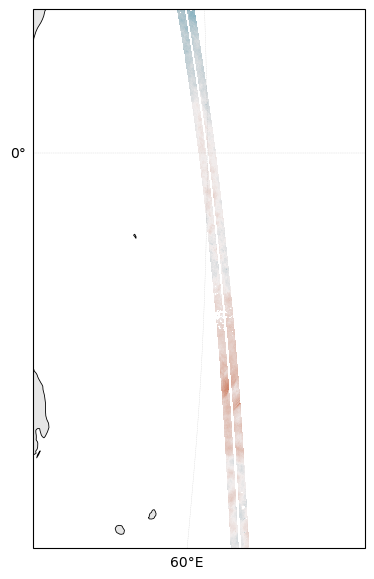

In [187]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cmocean
fig,ax = plt.subplots(figsize=(14,7),subplot_kw={'projection':ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}

sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], data_expert['ssha'], transform=ccrs.PlateCarree(),
                   cmap=cmocean.cm.balance, vmin = -1, vmax=1)
ax.set_extent([50,70,-22,8], crs=ccrs.PlateCarree())
plt.show()

## 3.1D- along-track spectra

In [188]:
def process_one_file(data, segment_length_km, overlap, max_gap_fraction, detrend,
                      lat_min, lat_max, lon_min, lon_max, remove_edges=None,
                      center_latitudes=None):
    """`center_latitudes`, if given, is a dict {'left': [...], 'right': [...]}
    of target central latitudes for each swath's segments (typically the
    Expert product's own segment `lat_mean` values), so that this file's
    segments are centered on exactly those latitudes instead of on an
    independently-built regular along-track grid. See
    `compute_pass_spectra`/`compute_swath_spectra` for details."""
    import traceback as _tb

    try:
        result = compute_pass_spectra(
            ssha=data['ssha'],
            latitude=data['latitude'],
            longitude=data['longitude'],
            cross_track_distance=data['cross_track_distance'],
            segment_length_km=segment_length_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
            detrend=detrend,
            remove_edges=remove_edges,
            center_latitudes=center_latitudes,
        )
    except Exception:
        return ( f'spectra error:\n{_tb.format_exc()}', None)

    #granule_name = Path(filepath).stem
    kept, wavenumber = [], None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                #seg._granule = granule_name
                kept.append(seg)

    return (kept, wavenumber)

In [189]:
processed_unsmooth = process_one_file(data_unsmoothed,SEGMENT_LENGTH_KM, OVERLAP, MAX_GAP_FRACTION, DETREND,
                                       LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, remove_edges = None,
#                                       center_latitudes = center_lats_by_swath,
                                      )

/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [190]:
all_segments_unsmooth, wavenumber_un = processed_unsmooth

In [191]:
center_lats_by_swath = {
    swath: np.array([s.lat_mean for s in all_segments_unsmooth if s.swath == swath])
    for swath in ('left', 'right')
}
{swath: len(v) for swath, v in center_lats_by_swath.items()}

{'left': 35, 'right': 36}

In [192]:
# Expert segments are computed first, on their own regular along-track
# grid (as before) -- these segment centroids become the latitude anchors
# the Unsmoothed segments below are matched to.
processed_expert   = process_one_file(data_expert,SEGMENT_LENGTH_KM, OVERLAP, MAX_GAP_FRACTION, DETREND,
                                       LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, remove_edges = None,
                                      center_latitudes = center_lats_by_swath,
                                      )
all_segments_expert, wavenumber_exp = processed_expert


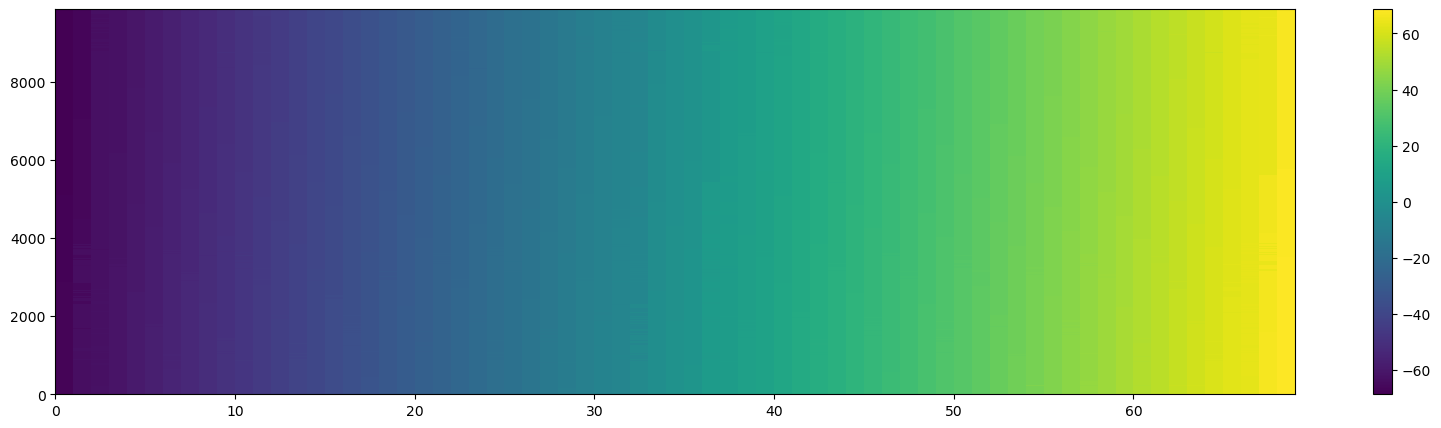

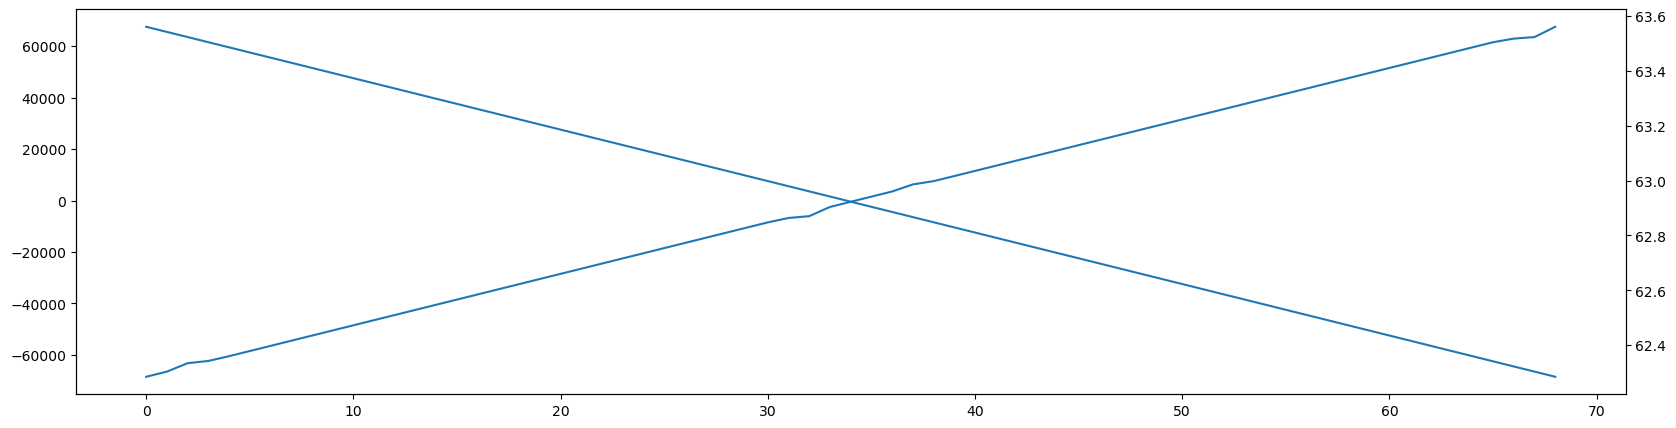

In [193]:
plt.figure(figsize=(20,5))
cs = plt.pcolormesh(data_expert['cross_track_distance']*1e-3)
plt.colorbar(cs)
np.nanmedian(data_expert['cross_track_distance'])

plt.figure(figsize=(20,5))
plt.plot(data_expert['cross_track_distance'][6000,:])
plt.twinx()
plt.plot(data_expert['longitude'][6000,:])

In [194]:
ds_segments_expert     = segments_to_dataset(all_segments_expert, wavenumber_exp)
ds_segments_unsmoothed = segments_to_dataset(all_segments_unsmooth, wavenumber_un)
print(f'Segment dataset (expert): {ds_segments_expert.sizes}')
print(f'Segment dataset (unsmoothed): {ds_segments_unsmoothed.sizes}')

Segment dataset (expert): Frozen({'segment': 70, 'wavenumber': 126})
Segment dataset (unsmoothed): Frozen({'segment': 71, 'wavenumber': 1050})


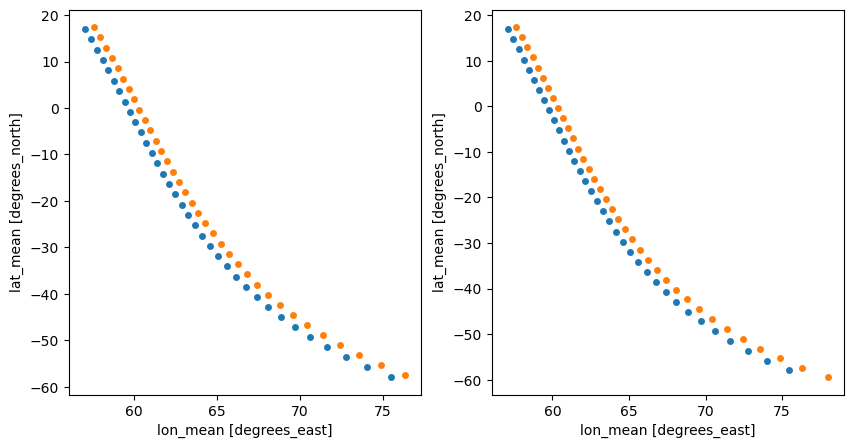

In [195]:
fig,axs = plt.subplots(1,2,figsize=(10,5))
ax = axs[0]
ds_segments_expert.where(ds_segments_expert.swath=='left',drop=True).plot.scatter(ax = ax, x='lon_mean',y='lat_mean')
ds_segments_expert.where(ds_segments_expert.swath=='right',drop=True).plot.scatter(ax = ax,x='lon_mean',y='lat_mean')

ax = axs[1]
ds_segments_unsmoothed.where(ds_segments_unsmoothed.swath=='left',drop=True).plot.scatter(ax = ax,x='lon_mean',y='lat_mean')
ds_segments_unsmoothed.where(ds_segments_unsmoothed.swath=='right',drop=True).plot.scatter(ax = ax,x='lon_mean',y='lat_mean')

## 4. Diagnostics- comparison

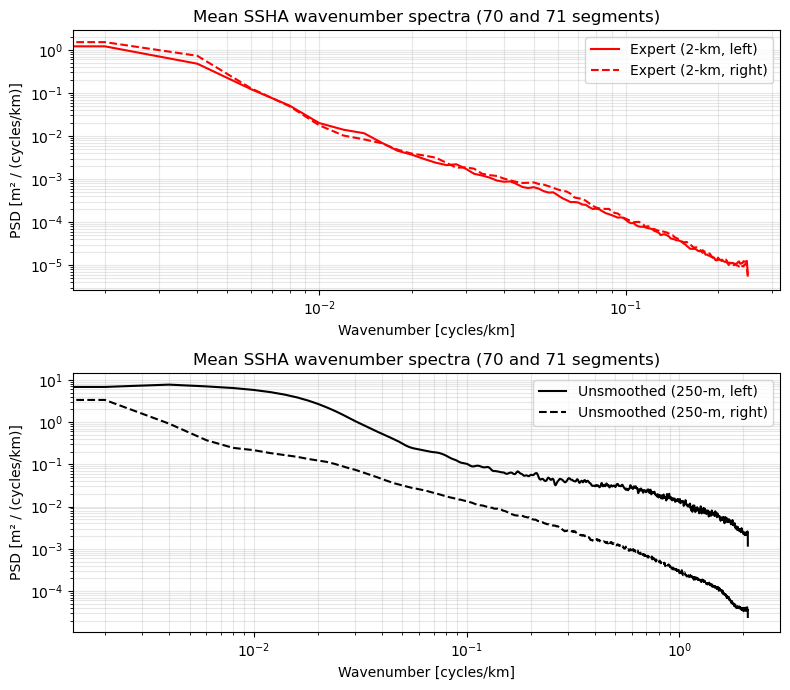

In [196]:
fig, axs = plt.subplots(2,1,figsize=(8,7))
ax = axs[0]
ds_segments_expert.where(ds_segments_expert.swath=='left',drop=True
                        ).mean('segment').psd.plot(ax=ax,xscale='log',yscale='log', c = "r", label = "Expert (2-km, left)")
ds_segments_expert.where(ds_segments_expert.swath=='right',drop=True
                        ).mean('segment').psd.plot(ax=ax,xscale='log',yscale='log', c = "r", ls = "--", label = "Expert (2-km, right)")
ax = axs[1]
ds_segments_unsmoothed.where(ds_segments_unsmoothed.swath=='left',drop=True
                        ).mean('segment').psd.plot(ax=ax,xscale='log',yscale='log', c = "k", label = "Unsmoothed (250-m, left)")
ds_segments_unsmoothed.where(ds_segments_unsmoothed.swath=='right',drop=True
                        ).mean('segment').psd.plot(ax=ax,xscale='log',yscale='log', c = "k", ls = "--", label = "Unsmoothed (250-m, right)")

for ax in axs:
    ax.grid();
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.set_ylabel("PSD [m² / (cycles/km)]")
    ax.set_title(f"Mean SSHA wavenumber spectra ({ds_segments_expert.segment.size} and {ds_segments_unsmoothed.segment.size} segments)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

Text(0.5, 1.0, 'Unsmoothed (250m)')

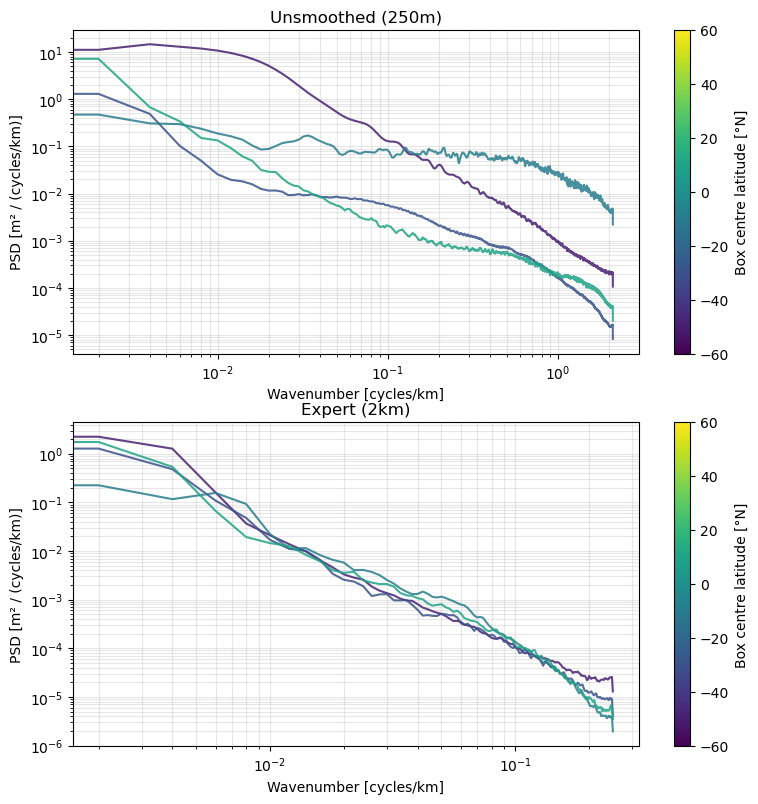

In [197]:
LAT_BIN_EDGES = np.arange(-60, 61, 20)  # adjust to the pass's latitude range
binned_spectra = [ds_segments_unsmoothed.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ds_segments_expert.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ]

fig, axs = plt.subplots(2,1,figsize=(8, 8))
for ax, binned in zip(axs,binned_spectra):
    lat_vals = binned["lat_mean_bins"].values
    norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
    cmap = plt.get_cmap("viridis")
    
    
    for i in range(binned.sizes["lat_mean_bins"]):
        lat_box = binned.isel(lat_mean_bins = i)
        ax.loglog(lat_box["wavenumber"], lat_box["psd"],color=cmap(norm(float(lat_box["lat_mean"]))),lw=1.5, alpha=0.85)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")
    
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.set_ylabel("PSD [m² / (cycles/km)]")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
axs[1].set_title("Expert (2km)")
axs[0].set_title("Unsmoothed (250m)")

## 5. Transfer function of the 250 m → 2 km smoothing filter

Going from the **Unsmoothed** (~250-m native) grid to the **Expert** (2-km) grid, the SWOT ground processing does two things:

1. **Smooths** the 250-m field with a 2-D, 17-point Hamming window (i.e. a 17-tap 1-D Hamming filter applied along-track and across-track), documented to have a half-power cutoff wavelength of $\simeq$6.28 km (Chelton 2024; see e.g. *"The impact of two-dimensional filtering on white noise spectra in SWOT along-track observations"*).
2. **Decimates** the smoothed field onto the coarser 2-km grid (posting ratio $\simeq$ 8, i.e. keeping roughly every 8th along-track sample of the 250-m grid).

Because our spectra are 1-D along-track wavenumber spectra (already averaged across cross-track pixels for each segment), only the **along-track** of the 2-D Hamming window matters for the along-track transfer function: for a field that's roughly homogeneous across-track, cross-track averaging reduces the noise on each column's estimate but does not by itself reshape the along-track spectrum.

The cells below:
- build the along-track power transfer function $|H(k)|^2$ of the 17-tap Hamming filter, and check its half-power wavelength against the documented ≈6.28 km value,
- use it, together with an aliasing/folding correction for the decimation step, to predict the Expert-product spectrum directly from the measured Unsmoothed spectrum,
- and compare that prediction against the Expert spectrum actually measured above.

**Caveat:** this treats the along-track transfer function as separable and 1-D, and ignores any additional processing between the raw 250-m KaRIn measurement and the 'Unsmoothed' product itself (e.g. on-board processor smoothing). Treat the comparison below as a diagnostic of how much of the Expert-vs-Unsmoothed spectral gap the documented 17-tap Hamming filter explains, not as an exact forward model.

In [198]:
# ── Transfer function of the 250-m -> 2-km SWOT smoothing filter ───────────
# The SWOT ground segment smooths the 250-m 'Unsmoothed' grid with a
# separable 2-D, 17-point Hamming window before decimating onto the 2-km
# 'Expert'/'Basic' grid (half-power cutoff wavelength ~ 6.28 km;
# Chelton 2024, arXiv:2604.14009). For along-track spectra, only the
# along-track marginal (a 17-tap 1-D Hamming filter at the ~250-m native
# spacing) shapes the transfer function.

N_TAPS = 17  # along-track length of the smoothing filter, in native (250-m) samples


def hamming_taps(n_taps: int = N_TAPS) -> np.ndarray:
    """Unit-DC-gain, n_taps-point Hamming filter."""
    h = np.hamming(n_taps)
    return h / h.sum()


def hamming_transfer_function(k, dx_native_km, n_taps: int = N_TAPS):
    """
    Power transfer function |H(k)|^2 of the along-track Hamming filter,
    evaluated at wavenumber(s) k [cycles/km].

    k may extend beyond the native Nyquist wavenumber (1 / (2*dx_native_km));
    H(k) is then evaluated using its natural periodicity in wavenumber,
    which is exactly what is needed to fold aliased wavenumbers back into
    the passband in predict_expert_psd() below.
    """
    k = np.atleast_1d(np.asarray(k, dtype=float))
    h = hamming_taps(n_taps)
    n = np.arange(n_taps) - (n_taps - 1) / 2.0
    phase = -2j * np.pi * dx_native_km * np.outer(k, n)     # (len(k), n_taps)
    H = (np.exp(phase) * h).sum(axis=1)
    return np.abs(H) ** 2


# ── Estimate the native / decimated grid spacings directly from the data ───
dx_native_km = 1.0 / (2.0 * wavenumber_un.max())    # Unsmoothed Nyquist -> spacing
dx_expert_km = 1.0 / (2.0 * wavenumber_exp.max())   # Expert Nyquist -> spacing
decim_factor = dx_expert_km / dx_native_km

print(f'Unsmoothed native spacing : {dx_native_km*1e3:6.1f} m  (Nyquist {wavenumber_un.max():.3f} cy/km)')
print(f'Expert grid spacing       : {dx_expert_km*1e3:6.1f} m  (Nyquist {wavenumber_exp.max():.3f} cy/km)')
print(f'Decimation factor         : {decim_factor:5.2f}  (nominal SWOT value: 8)')

# Sanity check against the documented half-power cutoff wavelength (~6.28 km)
k_dense = np.linspace(1e-4, wavenumber_un.max(), 20000)
H2_dense = hamming_transfer_function(k_dense, dx_native_km)
k_half = k_dense[np.argmin(np.abs(H2_dense - 0.5))]
print(f'Half-power wavenumber      : {k_half:.4f} cy/km  ->  wavelength {1/k_half:.2f} km  (documented: 6.28 km)')

Unsmoothed native spacing :  238.3 m  (Nyquist 2.098 cy/km)
Expert grid spacing       : 2001.2 m  (Nyquist 0.250 cy/km)
Decimation factor         :  8.40  (nominal SWOT value: 8)
Half-power wavenumber      : 0.1672 cy/km  ->  wavelength 5.98 km  (documented: 6.28 km)


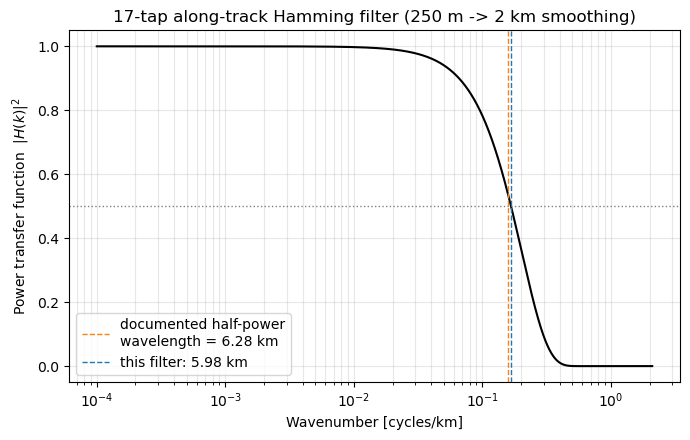

In [199]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_dense, H2_dense, c='k', lw=1.5)
ax.axhline(0.5, c='0.5', ls=':', lw=1)
ax.axvline(1 / 6.28, c='C1', ls='--', lw=1, label='documented half-power\nwavelength = 6.28 km')
ax.axvline(k_half, c='C0', ls='--', lw=1, label=f'this filter: {1/k_half:.2f} km')
ax.set_xscale('log')
ax.set_xlabel('Wavenumber [cycles/km]')
ax.set_ylabel(r'Power transfer function  $|H(k)|^2$')
ax.set_title(f'{N_TAPS}-tap along-track Hamming filter (250 m -> 2 km smoothing)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()

In [200]:
def predict_expert_psd(wavenumber_expert, wavenumber_unsmoothed, psd_unsmoothed,
                        dx_native_km, dx_expert_km, n_taps=N_TAPS, include_aliasing=True):
    """
    Predict the Expert-product PSD from a measured Unsmoothed PSD, using the
    along-track Hamming transfer function and (optionally) accounting for
    aliasing introduced by decimating the smoothed 250-m field onto the
    coarser 2-km grid.

        psd_predicted(k) = sum_{n=0}^{M-1} |H(k + n*fs_expert)|^2 * PSD_unsmoothed(k + n*fs_expert)

    where M = round(dx_expert_km / dx_native_km) is the decimation factor and
    fs_expert = 1 / dx_expert_km is the sampling (2x Nyquist) frequency of
    the decimated grid. n=0 is the direct (unaliased) term; n>=1 are higher
    native-grid wavenumbers that fold back into the Expert band once the
    smoothed field is subsampled.

    Parameters
    ----------
    wavenumber_expert : (n_k_exp,) array
        Wavenumber axis [cycles/km] on which to produce the prediction
        (typically the Expert product's own wavenumber axis).
    wavenumber_unsmoothed, psd_unsmoothed : (n_k_un,) arrays
        Measured Unsmoothed wavenumber axis and PSD to filter.
    dx_native_km, dx_expert_km : float
        Along-track sample spacing of the Unsmoothed and Expert grids.
    include_aliasing : bool
        If False, only the direct (unaliased) term is used, i.e. the naive
        psd_predicted(k) = |H(k)|^2 * PSD_unsmoothed(k).
    """
    wavenumber_expert = np.asarray(wavenumber_expert, dtype=float)
    decim = max(1, int(round(dx_expert_km / dx_native_km)))
    n_alias = decim if include_aliasing else 1
    fs_expert = 1.0 / dx_expert_km

    k_max_native = wavenumber_unsmoothed.max()
    psd_pred = np.zeros_like(wavenumber_expert)
    for n in range(n_alias):
        k_fold = wavenumber_expert + n * fs_expert
        H2 = hamming_transfer_function(k_fold, dx_native_km, n_taps=n_taps)
        psd_i = np.interp(k_fold, wavenumber_unsmoothed, psd_unsmoothed,
                           left=np.nan, right=np.nan)
        valid = k_fold <= k_max_native
        psd_pred += np.where(valid, H2 * psd_i, 0.0)
    return psd_pred

In [201]:
# ── 8.1 Low-level helpers: patch prep and the 2-D periodogram ──────────────

def _fill_nan_2d(patch: np.ndarray, max_nan_fraction: float = 0.15):
    """
    Fill small NaN gaps in a 2-D patch via sequential 1-D linear
    interpolation (rows, then any leftover columns). Returns None if the
    patch has too many NaNs to fill sensibly (caller should drop it).
    """
    patch = patch.copy()
    if np.isnan(patch).mean() > max_nan_fraction:
        return None
    for i in range(patch.shape[0]):
        row = patch[i]
        if np.isnan(row).any() and not np.isnan(row).all():
            patch[i] = _interp_nan_1d(row)
    for j in range(patch.shape[1]):
        col = patch[:, j]
        if np.isnan(col).any() and not np.isnan(col).all():
            patch[:, j] = _interp_nan_1d(col)
    return None if np.isnan(patch).any() else patch


def _patch_bounds_at_latitudes(lat_ref: np.ndarray, target_lats: Sequence[float],
                                n_lines_patch: int, max_patches: Optional[int] = None):
    """Row-index bounds (i0, i1) for `n_lines_patch`-row 2-D patches centered
    on a set of target latitudes, instead of evenly spread along the pass
    (cf. the `np.linspace` spread used by `extract_2d_patches` when no
    `center_latitudes` are given).

    `lat_ref` is the reference-column latitude array of the swath (same
    convention as `along_track_distance_km`'s reference column). For each
    target latitude, the nearest row is located and a patch of
    `n_lines_patch` rows is centered on it; targets whose patch would run
    off either end of the pass are dropped.

    If `target_lats` has more entries than `max_patches`, an evenly-spaced
    subset (by position in the input sequence, which is assumed to already
    be in along-track order) is selected first, matching the number/spirit
    of patches `extract_2d_patches` would otherwise have spread across the
    pass -- this keeps the per-file compute cost comparable to the
    unmatched behaviour rather than growing with however many target
    latitudes happen to be supplied.
    """
    lat_ref = _interp_nan_1d(np.asarray(lat_ref, dtype=float))
    n_rows = len(lat_ref)
    half = n_lines_patch // 2

    target_lats = np.asarray(target_lats, dtype=float)
    if max_patches is not None and len(target_lats) > max_patches:
        pick = np.linspace(0, len(target_lats) - 1, max_patches).round().astype(int)
        target_lats = target_lats[pick]

    bounds = []
    for target_lat in target_lats:
        center_idx = int(np.argmin(np.abs(lat_ref - target_lat)))
        i0 = center_idx - half
        i1 = i0 + n_lines_patch
        if i0 < 0 or i1 > n_rows:
            continue  # patch centered here would run off the pass
        bounds.append((i0, i1))
    return bounds


def _plane_detrend_2d(patch: np.ndarray) -> np.ndarray:
    """Remove the best-fit plane (a + b*x + c*y) from a 2-D patch. A
    per-axis 1-D detrend would not remove the real, large-amplitude
    cross-track 'bowl' in SSH(A) that comes from swath geometry."""
    n1, n2 = patch.shape
    y_idx, x_idx = np.mgrid[0:n1, 0:n2]
    A = np.column_stack([np.ones(n1 * n2), x_idx.ravel(), y_idx.ravel()])
    coeffs, *_ = np.linalg.lstsq(A, patch.ravel(), rcond=None)
    return patch - (A @ coeffs).reshape(n1, n2)


def _trim_to_multiple(patch: np.ndarray, Ma: int, Mc: int) -> np.ndarray:
    """Trim a patch so both dimensions are exact multiples of the
    along-track/cross-track decimation factors (required for the exact
    reshape-and-sum aliasing fold below)."""
    n1, n2 = patch.shape
    return patch[: n1 - (n1 % Ma), : n2 - (n2 % Mc)]


def periodogram_2d(patch: np.ndarray, dx1_km: float, dx2_km: float):
    """
    2-D power spectral density of a real patch via a 2-D Hann-tapered
    periodogram, two-sided on both axes.

    Returns (k1, k2, S2D) with k1 (axis 0, along-track) and k2 (axis 1,
    cross-track) in cycles/km (np.fft.fftfreq layout: 0, positive,
    ..., negative, ...), and S2D such that S2D.sum() * dk1 * dk2
    approximates the (tapered) patch variance (Parseval).
    """
    n1, n2 = patch.shape
    win2d = np.outer(np.hanning(n1), np.hanning(n2))
    win_norm = np.mean(win2d ** 2)

    F = np.fft.fft2(patch * win2d)
    S2D = (dx1_km * dx2_km) / (n1 * n2) * np.abs(F) ** 2 / win_norm

    k1 = np.fft.fftfreq(n1, d=dx1_km)
    k2 = np.fft.fftfreq(n2, d=dx2_km)
    return k1, k2, S2D

In [202]:
# ── 8.2 The core alias decomposition for one 2-D patch ──────────────────────

def alias_decompose_patch(patch: np.ndarray,
                           dx1_native_km: float, dx2_native_km: float,
                           dx1_expert_km: float, dx2_expert_km: float,
                           n_taps: int = N_TAPS):
    """
    Exact discrete along-track + cross-track alias decomposition of one
    2-D patch's periodogram.

    Uses the standard multirate-DSP identity for the expected PSD of a
    decimated-by-M stationary process: S_decimated[p] = sum_{r=0}^{M-1}
    S_native[p + r*N']. Because dx_expert is an exact integer multiple
    of dx_native on both axes here, this is implemented *exactly* (no
    interpolation) by reshaping the native FFT grid into (M, N') blocks
    and summing over the M axis - applied on both the along-track and
    cross-track dimensions.

    Returns k1_onesided (along-track wavenumber, cycles/km, >= 0),
    S1D_direct(k1), S1D_aliased(k1): one-sided along-track marginal
    spectra (doubled-bin convention, matching scipy.signal.periodogram
    as used elsewhere in this notebook), already integrated over the
    full Expert cross-track band. Returns None if the patch is too
    small relative to the decimation factors.
    """
    Ma = max(1, int(round(dx1_expert_km / dx1_native_km)))
    Mc = max(1, int(round(dx2_expert_km / dx2_native_km)))
    patch = _trim_to_multiple(patch, Ma, Mc)
    n1, n2 = patch.shape
    if n1 < Ma * 4 or n2 < Mc * 4:
        return None

    k1_native, k2_native, S2D_native = periodogram_2d(patch, dx1_native_km, dx2_native_km)

    H1 = hamming_transfer_function(k1_native, dx1_native_km, n_taps=n_taps)
    H2 = hamming_transfer_function(k2_native, dx2_native_km, n_taps=n_taps)
    S2D_filtered = S2D_native * H1[:, None] * H2[None, :]

    n1p, n2p = n1 // Ma, n2 // Mc

    # exact aliasing fold: sum of power over the Ma x Mc shifted replicas
    folded = S2D_filtered.reshape(Ma, n1p, n2).sum(axis=0)
    folded = folded.reshape(n1p, Mc, n2p).sum(axis=1)      # (n1p, n2p): direct + aliased
    direct = S2D_filtered[:n1p, :n2p]                       # (r=0, s=0) block only: direct term

    dk2 = k2_native[1] - k2_native[0]
    marg_total = folded.sum(axis=1) * dk2   # two-sided along k1, integrated over all k2
    marg_direct = direct.sum(axis=1) * dk2

    k1_expert = np.fft.fftfreq(n1p, d=dx1_expert_km)  # matches k1_native[:n1p] exactly (same dk)

    def _to_one_sided(marg, k1):
        pos = k1 >= 0
        k1_os, m_os = k1[pos].copy(), marg[pos].copy()
        interior = (k1_os > 0) & (k1_os < np.abs(k1).max())
        m_os[interior] *= 2.0     # fold in the mirrored negative-k1 contribution
        order = np.argsort(k1_os)
        return k1_os[order], m_os[order]

    k1_os, total_os = _to_one_sided(marg_total, k1_expert)
    _, direct_os = _to_one_sided(marg_direct, k1_expert)
    return k1_os, direct_os, total_os - direct_os

In [203]:
# ── 8.3 Patch extraction + the single top-level, per-file entry point ──────

def extract_2d_patches(ssha: np.ndarray, mask: np.ndarray,
                        n_lines_patch: int = 1000, max_patches: int = 6,
                        max_nan_fraction: float = 0.15,
                        latitude: Optional[np.ndarray] = None,
                        center_latitudes: Optional[Sequence[float]] = None):
    """Slice one swath into along-track patches, fill small gaps, drop
    patches with too many, and plane-detrend each surviving patch.

    By default (`center_latitudes=None`), `max_patches` patches of
    `n_lines_patch` rows are spread evenly across the pass (the original
    behaviour: independent of any other product's grid).

    If `center_latitudes` is given (a sequence of target latitudes, e.g.
    the Expert product's own segment/patch centroids for this swath), each
    patch is instead centered on the nearest along-track row to one of
    those latitudes -- so the Unsmoothed patches used here share their
    central latitude with the Expert footprints they'll be compared
    against. `latitude` (same shape as `ssha`) must be supplied in that
    case, to locate the target rows. See `_patch_bounds_at_latitudes`.
    """
    cols = np.where(mask)[0]
    sub = ssha[:, cols]
    n_rows = sub.shape[0]
    if center_latitudes is not None:
        if latitude is None:
            raise ValueError("latitude= is required when center_latitudes is given.")
        ref_col = cols[len(cols) // 2]
        lat_ref = latitude[:, ref_col]
        bounds = _patch_bounds_at_latitudes(lat_ref, center_latitudes,
                                             n_lines_patch, max_patches=max_patches)
        starts = [i0 for i0, i1 in bounds]
    else:
        starts = np.linspace(0, max(n_rows - n_lines_patch, 0), max_patches).astype(int)
    patches = []
    for s in starts:
        block = sub[s:s + n_lines_patch, :]
        if block.shape[0] < n_lines_patch:
            continue
        filled = _fill_nan_2d(block, max_nan_fraction=max_nan_fraction)
        if filled is not None:
            patches.append(_plane_detrend_2d(filled))
    return patches


def band_energy(k: np.ndarray, S: np.ndarray, k_lo: float, k_hi: float) -> float:
    sel = (k >= k_lo) & (k <= k_hi)
    return float(np.trapezoid(S[sel], k[sel])) if sel.sum() >= 2 else np.nan


def estimate_aliased_energy_fraction(data_unsmoothed: dict, data_expert: dict,
                                      band_km: tuple = (30.0, 10.0),
                                      remove_edges_m: float = 10e3,
                                      n_lines_patch: int = 1000,
                                      max_patches: int = 6,
                                      n_taps: int = N_TAPS,
                                      center_latitudes: Optional[dict] = None):
    """
    Full per-file pipeline: for each swath, extract 2-D Unsmoothed
    patches, run the alias decomposition on each, average the resulting
    direct/aliased marginal spectra across patches, and integrate both
    over `band_km` (given as (long_wavelength_km, short_wavelength_km))
    to get the aliased energy fraction in that along-track band.

    This is the single function to call once per granule when scaling
    this up to many files: pass in freshly-loaded data_unsmoothed /
    data_expert dicts, collect the returned dict, move on.

    center_latitudes : dict, optional
        {'left': [...], 'right': [...]} of target central latitudes per
        swath (e.g. the Expert product's own segment centroids, such as
        `center_lats_by_swath` from Section 3). If given, the Unsmoothed
        2-D patches for each swath are centered on these latitudes
        (`extract_2d_patches`'s `center_latitudes`) instead of being
        spread independently across the pass. See Section 8's discussion
        for the trade-off this introduces.

    Returns
    -------
    dict, keyed by swath ('left', 'right'), each an inner dict with:
        'k', 'direct_mean', 'aliased_mean'  - averaged marginal spectra
        'direct_energy', 'aliased_energy'   - band-integrated energy
        'aliased_fraction'                  - aliased / (direct + aliased)
        'n_patches'                         - number of patches actually used
    """
    k_lo, k_hi = 1.0 / band_km[0], 1.0 / band_km[1]

    left_ne, right_ne = split_left_right_swaths(data_unsmoothed['cross_track_distance'],
                                                 remove_edges=remove_edges_m)
    left_exp_ne, right_exp_ne = split_left_right_swaths(data_expert['cross_track_distance'],
                                                          remove_edges=remove_edges_m)

    dx1_native_km = 1.0 / (2.0 * wavenumber_un.max())   # from Section 5, ~0.25 km
    dx1_expert_km = 1.0 / (2.0 * wavenumber_exp.max())  # from Section 5, ~2 km

    results = {}
    for swath, mask_un, mask_exp in (('left', left_ne, left_exp_ne),
                                      ('right', right_ne, right_exp_ne)):
        dx2_native_km = cross_track_spacing_km(data_unsmoothed['cross_track_distance'], mask_un)
        dx2_expert_km = cross_track_spacing_km(data_expert['cross_track_distance'], mask_exp)

        patches = extract_2d_patches(data_unsmoothed['ssha'], mask_un,
                                      n_lines_patch=n_lines_patch, max_patches=max_patches,
                                      latitude=data_unsmoothed['latitude'],
                                      center_latitudes=(center_latitudes.get(swath)
                                                         if center_latitudes else None))

        direct_curves, aliased_curves, k_ref = [], [], None
        for patch in patches:
            out = alias_decompose_patch(patch, dx1_native_km, dx2_native_km,
                                         dx1_expert_km, dx2_expert_km, n_taps=n_taps)
            if out is None:
                continue
            k1_os, direct_os, aliased_os = out
            k_ref = k1_os
            direct_curves.append(direct_os)
            aliased_curves.append(aliased_os)

        if not direct_curves:
            results[swath] = None
            continue

        direct_mean = np.nanmean(np.array(direct_curves), axis=0)
        aliased_mean = np.nanmean(np.array(aliased_curves), axis=0)

        direct_energy = band_energy(k_ref, direct_mean, k_lo, k_hi)
        aliased_energy = band_energy(k_ref, aliased_mean, k_lo, k_hi)
        frac = aliased_energy / (direct_energy + aliased_energy)

        results[swath] = dict(k=k_ref, direct_mean=direct_mean, aliased_mean=aliased_mean,
                               direct_energy=direct_energy, aliased_energy=aliased_energy,
                               aliased_fraction=frac, n_patches=len(direct_curves))
    return results
    

In [204]:
# ── Fast, real-data-only estimate of cross-track energy beyond the ─────────
#    Expert product's cross-track Nyquist wavenumber ───────────────────────

N_CHUNKS = 8               # number of along-track chunks sampled across the pass
CHUNK_LINES = 200          # ~50 km of along-track lines per chunk at 250 m spacing
MIN_VALID_FRACTION = 0.9   # skip rows with too many NaNs across the swath


def cross_track_spacing_km(cross_track_distance, mask):
    """Estimate the native cross-track pixel spacing (km) for one swath."""
    xt = np.asarray(cross_track_distance, dtype=float)
    if xt.ndim == 2:
        xt = np.nanmedian(xt, axis=0)
    xt_swath = np.sort(xt[mask])
    d = np.diff(xt_swath)
    d = d[d > 0]
    spacing = float(np.median(d))
    # cross_track_distance is in metres in the SWOT products used above
    return spacing / 1000.0


def cross_track_energy_beyond_nyquist(ssha, mask, dx_across_km, l_nyquist,
                                       n_chunks=N_CHUNKS, chunk_lines=CHUNK_LINES,
                                       min_valid_fraction=MIN_VALID_FRACTION):
    """
    Average the cross-track periodogram (FFT across pixel columns, one
    along-track line at a time) over several along-track chunks of a
    swath, sampled across the pass.

    Returns (wavenumber, mean_psd, fraction_of_energy_beyond_l_nyquist).
    """
    cols = np.where(mask)[0]
    sub = ssha[:, cols]
    n_lines, n_pix = sub.shape

    starts = np.linspace(0, max(n_lines - chunk_lines, 0), n_chunks).astype(int)
    win = signal.get_window('hann', n_pix)
    win_norm = (win ** 2).mean()

    all_pxx = []
    for s in starts:
        block = sub[s:s + chunk_lines, :]
        for row in block:
            valid = ~np.isnan(row)
            if valid.mean() < min_valid_fraction:
                continue
            row_filled = _interp_nan_1d(row)
            row_d = signal.detrend(row_filled, type='constant')
            tapered = row_d * win
            freqs, pxx = signal.periodogram(tapered, fs=1.0 / dx_across_km,
                                             window='boxcar', detrend=False,
                                             scaling='density')
            all_pxx.append(pxx / win_norm)

    if not all_pxx:
        raise RuntimeError('No valid cross-track rows found - loosen MIN_VALID_FRACTION '
                            'or check the swath mask.')

In [205]:
BAND_KM = (30.0, 10.0)  # (long wavelength, short wavelength), matches the question asked
MAX_PATCHES = 18

# center_lats_by_swath (built in Section 3, from the Expert product's own
# kept segment centroids) is reused here so the Unsmoothed 2-D patches are
# centered on the same latitudes as the Expert grid, rather than being an
# independently-spaced sample of the pass. See the note above.
aliased_results = estimate_aliased_energy_fraction(data_unsmoothed, data_expert, band_km=BAND_KM,
                                                     center_latitudes=center_lats_by_swath,max_patches=MAX_PATCHES)

for swath, r in aliased_results.items():
    if r is None:
        print(f'{swath:5s} swath: no usable patches (check gap/land coverage for this file)')
        continue
    print(f'{swath:5s} swath (n_patches={r["n_patches"]}): '
          f'direct={r["direct_energy"]:.4e} m^2, aliased={r["aliased_energy"]:.4e} m^2  ->  '
          f'{r["aliased_fraction"]*100:5.1f}% of {BAND_KM[0]:.0f}-{BAND_KM[1]:.0f} km energy is aliased')

/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


left  swath (n_patches=18): direct=3.8517e-02 m^2, aliased=1.2033e-02 m^2  ->   23.8% of 30-10 km energy is aliased
right swath (n_patches=17): direct=9.1785e-05 m^2, aliased=3.2052e-05 m^2  ->   25.9% of 30-10 km energy is aliased


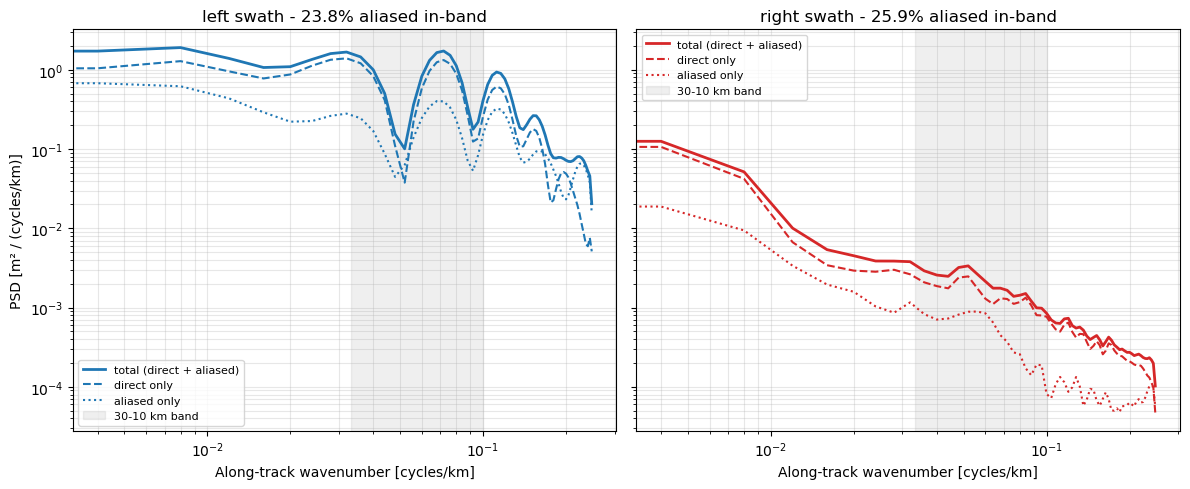

In [206]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {'left': 'C0', 'right': 'C3'}

for ax, swath in zip(axs, ('left', 'right')):
    r = aliased_results.get(swath)
    if r is None:
        continue
    c = colors[swath]
    ax.loglog(r['k'], r['direct_mean'] + r['aliased_mean'], c=c, lw=2,
              label='total (direct + aliased)')
    ax.loglog(r['k'], r['direct_mean'], c=c, lw=1.5, ls='--', label='direct only')
    ax.loglog(r['k'], r['aliased_mean'], c=c, lw=1.5, ls=':', label='aliased only')
    ax.axvspan(1 / BAND_KM[0], 1 / BAND_KM[1], color='0.5', alpha=0.12,
              label=f'{BAND_KM[0]:.0f}-{BAND_KM[1]:.0f} km band')
    ax.set_title(f'{swath} swath - {r["aliased_fraction"]*100:.1f}% aliased in-band')
    ax.set_xlabel('Along-track wavenumber [cycles/km]')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
fig.tight_layout()

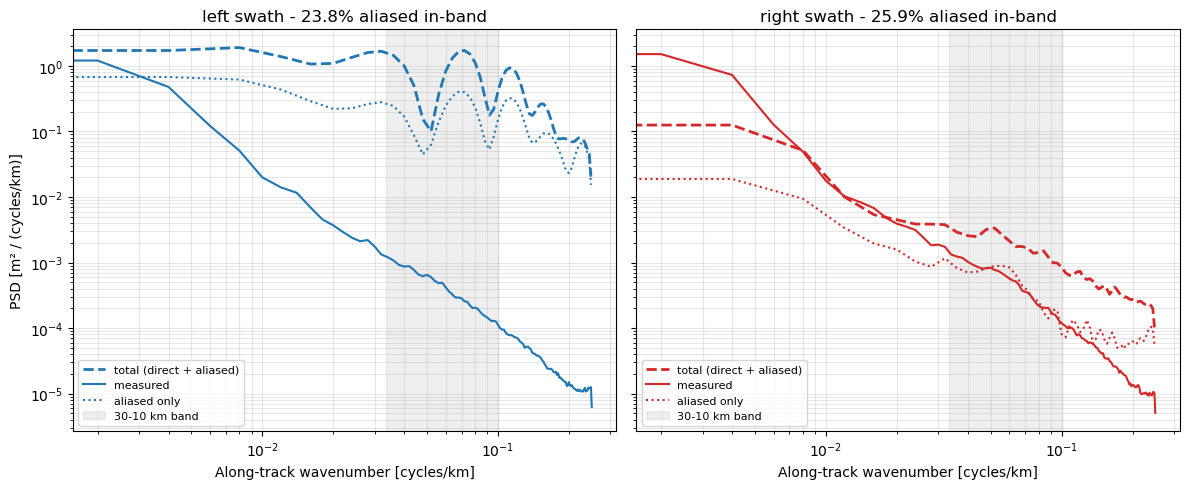

In [207]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {'left': 'C0', 'right': 'C3'}

for ax, swath in zip(axs, ('left', 'right')):
    r = aliased_results.get(swath)
    ex = ds_segments_expert.where(ds_segments_expert.swath == swath, drop=True).mean('segment')
    if r is None:
        continue
    c = colors[swath]
    ax.loglog(r['k'], r['direct_mean'] + r['aliased_mean'], c=c, ls='--',lw=2,
              label='total (direct + aliased)')
    ax.loglog(ex['wavenumber'], ex['psd'], c=c, lw=1.5, ls='-', label='measured')
    #ax.loglog(r['k'], r['direct_mean'], c=c, lw=1.5, ls='--', label='direct only')
    ax.loglog(r['k'], r['aliased_mean'], c=c, lw=1.5, ls=':', label='aliased only')
    ax.axvspan(1 / BAND_KM[0], 1 / BAND_KM[1], color='0.5', alpha=0.12,
              label=f'{BAND_KM[0]:.0f}-{BAND_KM[1]:.0f} km band')
    ax.set_title(f'{swath} swath - {r["aliased_fraction"]*100:.1f}% aliased in-band')
    ax.set_xlabel('Along-track wavenumber [cycles/km]')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
fig.tight_layout()

In [208]:
def extract_2d_patches_indexed(data, mask, n_lines_patch=500, max_patches=6,
                                max_nan_fraction=0.15, center_latitudes=None):
    """
    Same patch extraction as extract_2d_patches() (Section 8.3), but also
    keeps each patch's along-track row range and reference lat/lon, so it
    can be matched to the corresponding footprint in another product's
    grid - mirrors the segment-matching approach in Section 6.

    `center_latitudes`, if given, centers each patch on the nearest row to
    one of these latitudes (e.g. the Expert product's own segment
    centroids) instead of spreading patches evenly across the pass - same
    option as extract_2d_patches() in Section 8.3, kept in sync here so
    8.6's "matched validation" patches are drawn from the same footprints
    as 8.3's, rather than an independently-spread set that then gets
    matched to Expert only after the fact.
    """
    cols = np.where(mask)[0]
    sub = data['ssha'][:, cols]
    ref_col = cols[len(cols) // 2]
    lat_ref_full = data['latitude'][:, ref_col]
    lon_ref_full = data['longitude'][:, ref_col]

    n_rows = sub.shape[0]
    if center_latitudes is not None:
        bounds = _patch_bounds_at_latitudes(lat_ref_full, center_latitudes,
                                             n_lines_patch, max_patches=max_patches)
        starts = [i0 for i0, i1 in bounds]
    else:
        starts = np.linspace(0, max(n_rows - n_lines_patch, 0), max_patches).astype(int)

    patches = []
    for s in starts:
        i0, i1 = int(s), int(s) + n_lines_patch
        block = sub[i0:i1, :]
        if block.shape[0] < n_lines_patch:
            continue
        filled = _fill_nan_2d(block, max_nan_fraction=max_nan_fraction)
        if filled is None:
            continue
        patches.append(dict(patch=_plane_detrend_2d(filled), i0=i0, i1=i1,
                            lat_chunk=lat_ref_full[i0:i1], lon_chunk=lon_ref_full[i0:i1]))
    return patches
    
def find_matching_expert_rows(lat_chunk, lon_chunk, data_expert, expert_mask):
    """Row range in the Expert grid whose footprint best matches the
    start/end of a patch's along-track reference track (nearest-point
    match on the swath's reference column) - same idea as Section 6's
    segment matching, applied to along-track index ranges here."""
    cols_e = np.where(expert_mask)[0]
    ref_col_e = cols_e[len(cols_e) // 2]
    lat_e = data_expert['latitude'][:, ref_col_e]
    lon_e = data_expert['longitude'][:, ref_col_e]

    def nearest_row(lat0, lon0):
        d = _haversine_km(lat0, lon0, lat_e, lon_e)
        return int(np.nanargmin(d))

    j0 = nearest_row(lat_chunk[0], lon_chunk[0])
    j1 = nearest_row(lat_chunk[-1], lon_chunk[-1])
    return tuple(sorted((j0, j1 + 1)))


def extract_and_fill_patch(data, mask, i0, i1, max_nan_fraction=0.15):
    """Extract + gap-fill a single (i0:i1) x mask patch (no plane detrend -
    periodogram_1d_along_track below does its own 1-D detrend per column,
    matching compute_swath_spectra()'s convention)."""
    cols = np.where(mask)[0]
    block = data['ssha'][i0:i1, :][:, cols]
    return _fill_nan_2d(block, max_nan_fraction=max_nan_fraction)


def periodogram_1d_along_track(patch2d, dx_km, detrend='linear', window='hann'):
    """Along-track PSD of a plain, already-gridded 2-D patch (mean over
    cross-track columns), one-sided - same convention as
    compute_swath_spectra() elsewhere in this notebook."""
    n_along, n_across = patch2d.shape
    win = signal.get_window(window, n_along)
    win_norm = (win ** 2).mean()
    col_psds = []
    for c in range(n_across):
        col_d = signal.detrend(patch2d[:, c], type=detrend) if detrend else patch2d[:, c]
        tapered = col_d * win
        freqs, pxx = signal.periodogram(tapered, fs=1.0 / dx_km,
                                         window='boxcar', detrend=False, scaling='density')
        col_psds.append(pxx / win_norm)
    return freqs, np.mean(col_psds, axis=0)

In [209]:
# ── 8.6b Per-file, patch-matched driver (same "one function per file" ──────
#         pattern as estimate_aliased_energy_fraction in Section 8.3) ───────

def matched_patch_validation(data_unsmoothed, data_expert, remove_edges_m=10e3,
                              n_lines_patch=1000, max_patches=6, n_taps=N_TAPS,
                              center_latitudes=None):
    """
    For each swath: extract Unsmoothed patches, run the Section 8.2 alias
    decomposition on each to get a predicted (direct+aliased) spectrum,
    find the matching real Expert-grid rows for that same footprint, and
    compute the actual measured Expert spectrum there. Returns, per
    swath, a list of per-patch dicts with matched predicted/measured
    curves (all on the same wavenumber grid, ready to stack for a
    median/IQR summary) - deploys the same way as
    estimate_aliased_energy_fraction() in Section 8.3.

    center_latitudes : dict, optional
        {'left': [...], 'right': [...]}; if given, patches are centered on
        these latitudes (e.g. center_lats_by_swath from Section 3) instead
        of spread independently across the pass, same as Section 8.3.

    Note: this fixes a pre-existing bug where the along-track native/Expert
    spacings were referenced as undefined names (`dx_native_km`,
    `dx_expert_km`); they are now derived from `wavenumber_un`/
    `wavenumber_exp` exactly as in `estimate_aliased_energy_fraction`
    (Section 8.3).
    """
    dx1_native_km = 1.0 / (2.0 * wavenumber_un.max())
    dx1_expert_km = 1.0 / (2.0 * wavenumber_exp.max())

    left_ne, right_ne = split_left_right_swaths(data_unsmoothed['cross_track_distance'],
                                                  remove_edges=remove_edges_m)
    left_exp_ne, right_exp_ne = split_left_right_swaths(data_expert['cross_track_distance'],
                                                          remove_edges=remove_edges_m)

    results = {'left': [], 'right': []}
    for swath, mask_un, mask_exp in (('left', left_ne, left_exp_ne),
                                      ('right', right_ne, right_exp_ne)):
        dx2_native_km = cross_track_spacing_km(data_unsmoothed['cross_track_distance'], mask_un)
        dx2_expert_km = cross_track_spacing_km(data_expert['cross_track_distance'], mask_exp)

        patches = extract_2d_patches_indexed(data_unsmoothed, mask_un,
                                              n_lines_patch=n_lines_patch, max_patches=max_patches,
                                              center_latitudes=(center_latitudes.get(swath)
                                                                 if center_latitudes else None))

        for p in patches:
            out = alias_decompose_patch(p['patch'], dx1_native_km, dx2_native_km,
                                         dx1_expert_km, dx2_expert_km, n_taps=n_taps)
            if out is None:
                continue
            k_pred, direct_os, aliased_os = out
            psd_pred_total = direct_os + aliased_os

            j0, j1 = find_matching_expert_rows(p['lat_chunk'], p['lon_chunk'], data_expert, mask_exp)
            if j1 - j0 < 16:
                continue
            expert_patch = extract_and_fill_patch(data_expert, mask_exp, j0, j1)
            if expert_patch is None:
                continue
            k_meas, psd_meas = periodogram_1d_along_track(expert_patch, dx1_expert_km)
            psd_meas_i = np.interp(k_pred, k_meas, psd_meas, left=np.nan, right=np.nan)

            results[swath].append(dict(k=k_pred, psd_pred=psd_pred_total, psd_meas=psd_meas_i,
                                       psd_direct=direct_os, psd_aliased=aliased_os,
                                       lat_mean=float(np.nanmean(p['lat_chunk']))))
    return results

REMOVE_EDGES_M = 5e3
patch_match_results = matched_patch_validation(data_unsmoothed, data_expert,
                                                remove_edges_m=REMOVE_EDGES_M,
                                                center_latitudes=center_lats_by_swath,
                                              max_patches=MAX_PATCHES)
for swath in ('left', 'right'):
    print(f'{swath:5s} swath: {len(patch_match_results[swath])} matched patches')

/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


left  swath: 15 matched patches
right swath: 16 matched patches


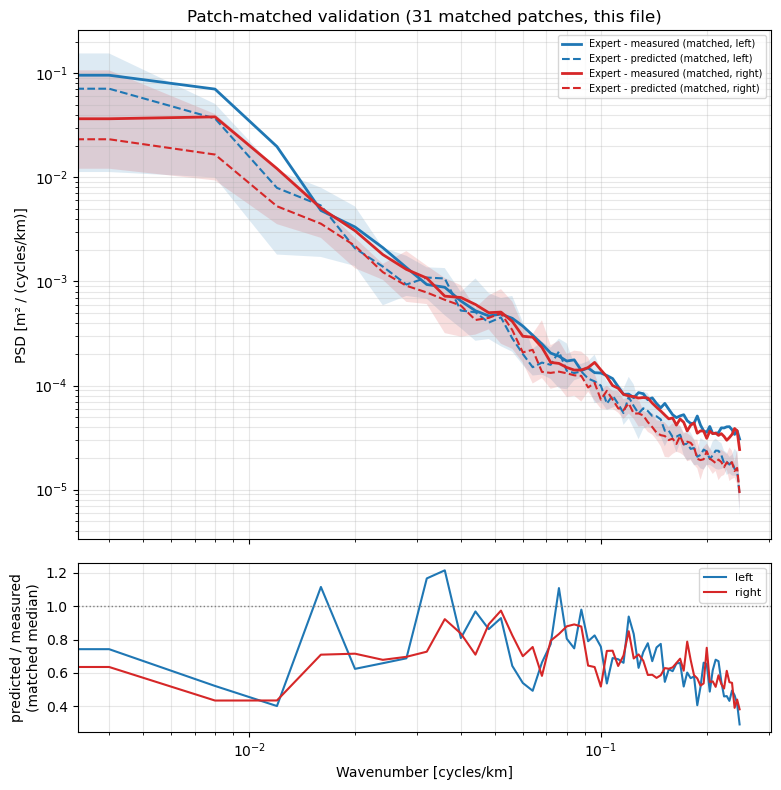

In [210]:

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = patch_match_results[swath]
    if not recs:
        continue
    k = recs[0]['k']
    pred_stack = np.array([r['psd_pred'] for r in recs])
    meas_stack = np.array([r['psd_meas'] for r in recs])

    pred_median = np.nanmedian(pred_stack, axis=0)
    pred_lo, pred_hi = np.nanpercentile(pred_stack, [25, 75], axis=0)
    meas_median = np.nanmedian(meas_stack, axis=0)

    ax = axs[0]
    ax.fill_between(k, pred_lo, pred_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, meas_median, c=c, lw=2, label=f'Expert - measured (matched, {swath})')
    ax.loglog(k, pred_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (matched, {swath})')

    # naive Section 8.4 curve: population-averaged prediction, no per-patch matching
    naive = None#aliased_results.get(swath)
    if naive is not None:
        ax.loglog(naive['k'], naive['direct_mean'] + naive['aliased_mean'], c=c, lw=1, ls=':',
                  alpha=0.7, label=f'Expert - predicted (unmatched, Sec. 8.4, {swath})')

    axs[1].semilogx(k, pred_median / meas_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured\n(matched median)')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
fig.tight_layout()

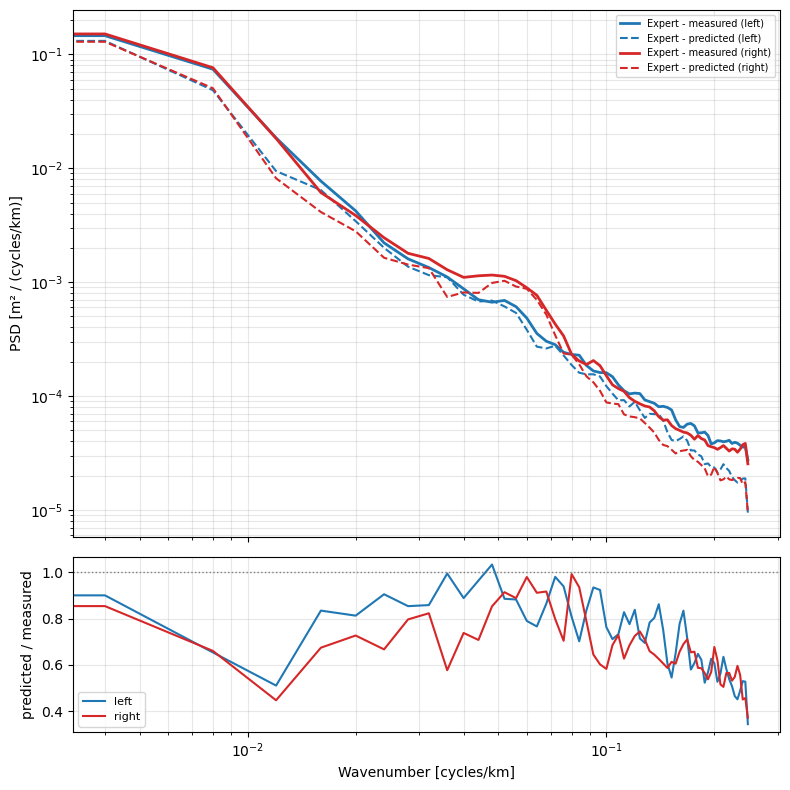

In [211]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = patch_match_results[swath]
    if not recs:
        continue
    k = recs[0]['k']
    pred_stack = np.array([r['psd_pred'] for r in recs])
    meas_stack = np.array([r['psd_meas'] for r in recs])

    pred_mean = np.nanmean(pred_stack, axis=0)
    meas_mean = np.nanmean(meas_stack, axis=0)

    ax = axs[0]
    ax.loglog(k, meas_mean, c=c, lw=2, label=f'Expert - measured ({swath})')
    ax.loglog(k, pred_mean, c=c, lw=1.5, ls='--', label=f'Expert - predicted ({swath})')

    # naive Section 8.4 curve: population-averaged prediction, no per-patch matching
    naive = None#aliased_results.get(swath)
    if naive is not None:
        ax.loglog(naive['k'], naive['direct_mean'] + naive['aliased_mean'], c=c, lw=1, ls=':',
                  alpha=0.7, label=f'Expert - predicted (unmatched, Sec. 8.4, {swath})')

    axs[1].semilogx(k, pred_mean / meas_mean, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
fig.tight_layout()

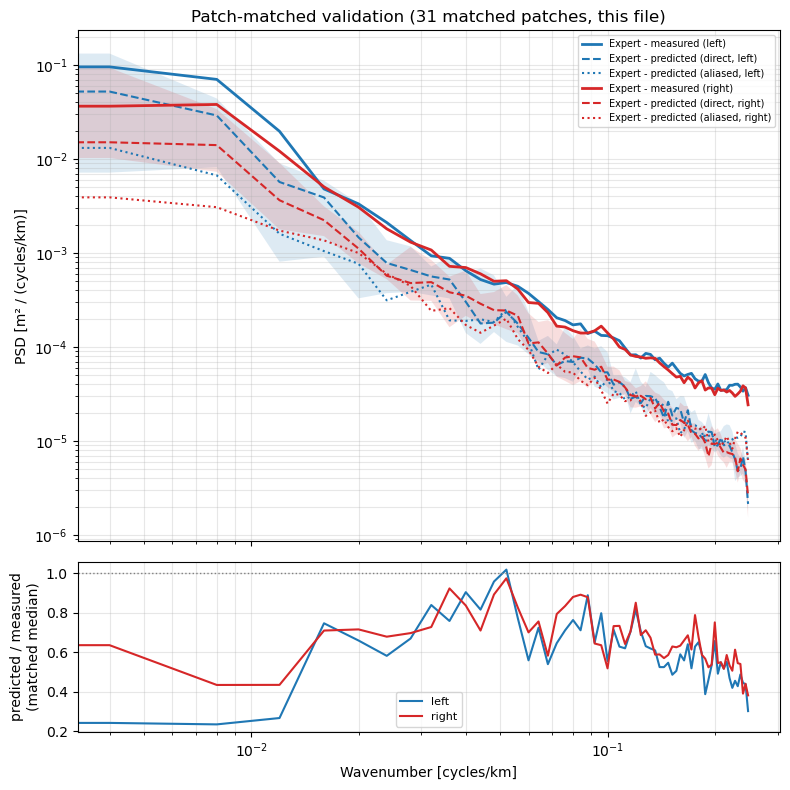

In [212]:
# ── 8.6c Matched median/IQR vs. the naive (unmatched, Section 8.4) curve ───
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = patch_match_results[swath]
    if not recs:
        continue
    k = recs[0]['k']
    direct_stack = np.array([r['psd_direct'] for r in recs])
    aliased_stack = np.array([r['psd_aliased'] for r in recs])
    meas_stack = np.array([r['psd_meas'] for r in recs])

    direct_median = np.nanmedian(direct_stack, axis=0)
    direct_lo, direct_hi = np.nanpercentile(direct_stack, [25, 75], axis=0)
    aliased_median = np.nanmedian(aliased_stack, axis=0)
    aliased_lo, aliased_hi = np.nanpercentile(aliased_stack, [25, 75], axis=0)
    meas_median = np.nanmedian(meas_stack, axis=0)

    ax = axs[0]
    ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, meas_median, c=c, lw=2, label=f'Expert - measured ({swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, pred_median / meas_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured\n(matched median)')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
fig.tight_layout()

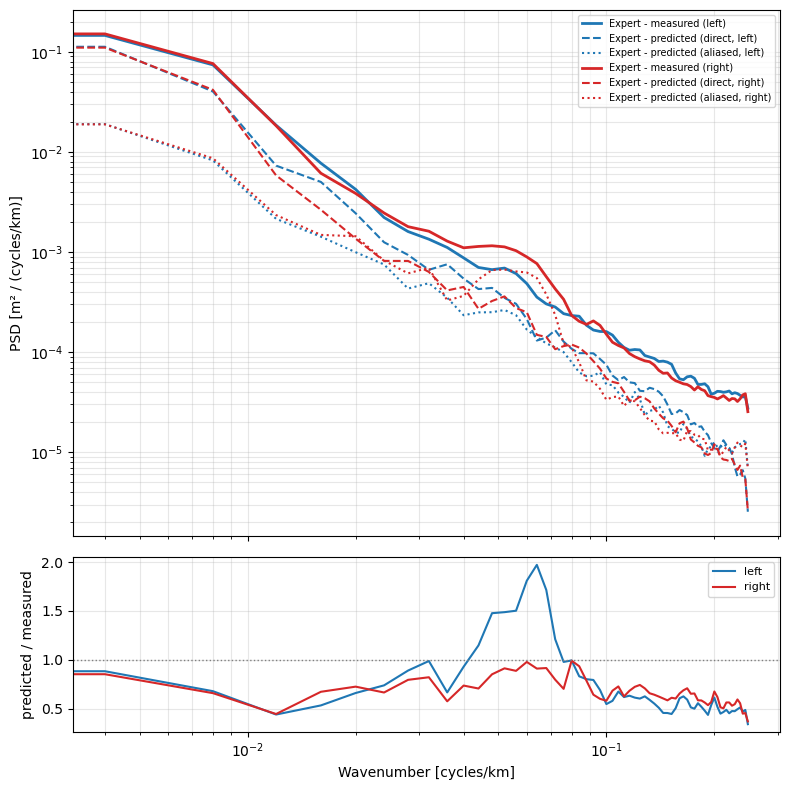

In [213]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = patch_match_results[swath]
    if not recs:
        continue
    k = recs[0]['k']
    direct_stack = np.array([r['psd_direct'] for r in recs])
    aliased_stack = np.array([r['psd_aliased'] for r in recs])
    meas_stack = np.array([r['psd_meas'] for r in recs])

    direct_mean = np.nanmean(direct_stack, axis=0)
    aliased_mean = np.nanmean(aliased_stack, axis=0)
    meas_mean = np.nanmean(meas_stack, axis=0)

    ax = axs[0]
    ax.loglog(k, meas_mean, c=c, lw=2, label=f'Expert - measured ({swath})')
    ax.loglog(k, direct_mean, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_mean, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, pred_mean / meas_mean, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
fig.tight_layout()

In [214]:
def flatten_alias_segments(
    results: dict,
    lat_min: Optional[float] = None,
    lat_max: Optional[float] = None,
    lon_min: Optional[float] = None,
    lon_max: Optional[float] = None,
):
    """
    Return a simple list of AliasSegmentSpectrum objects.

    This is the alias equivalent of your `all_segments_unsmooth`.
    """

    output = []

    for result in results.values():

        for segment in result.segments:

            if lat_min is not None and segment.lat_mean < lat_min:
                continue

            if lat_max is not None and segment.lat_mean > lat_max:
                continue

            if lon_min is not None and segment.lon_mean < lon_min:
                continue

            if lon_max is not None and segment.lon_mean > lon_max:
                continue

            output.append(segment)

    return output
    
def segments_to_dataset(
    segments: Sequence[AliasSegmentSpectrum],
) -> "xr.Dataset":
    """
    Pack a flat list of AliasSegmentSpectrum objects (e.g. from
    `flatten_alias_segments`) into a single xarray.Dataset with dimensions
    ("segment", "wavenumber").

    Every segment must share the same wavenumber-axis length. With
    `compute_alias_pass_spectra` / `compute_alias_swath_spectra` this is
    guaranteed for every segment produced with the same
    (segment_length_km, dx1_native_km, dx1_expert_km) -- including
    segments from different swaths and different files -- so results from
    many granules can be concatenated directly with this function (e.g.
    `xr.concat([segments_to_dataset(f) for f in per_file_segments],
    dim="segment")`, or simply passing the combined segment list from all
    files at once, as done here).

    Raises
    ------
    ValueError
        If the segments do not all share the same wavenumber-axis length
        (this would mean they came from calls with different
        segment_length_km / dx1_native_km / dx1_expert_km).
    """

    if xr is None:
        raise ImportError(
            "xarray is required for segments_to_dataset()."
        )

    if not segments:
        raise ValueError("No segments to pack.")

    lengths = {len(s['k']) for s in segments}

    if len(lengths) > 1:
        raise ValueError(
            f"Segments have inconsistent wavenumber-axis lengths "
            f"{sorted(lengths)}; they must all come from calls with "
            "identical segment_length_km, dx1_native_km and "
            "dx1_expert_km."
        )

    wavenumber = segments[0]['k']

    direct_psd = np.stack([s['psd_direct'] for s in segments], axis=0)
    aliased_psd = np.stack([s['psd_aliased'] for s in segments], axis=0)
    total_psd = np.stack([s['psd_pred'] for s in segments], axis=0)
    meas_psd = np.stack([s['psd_meas'] for s in segments], axis=0)

    return xr.Dataset(
        data_vars=dict(
            direct_psd=(
                ["segment", "wavenumber"],
                direct_psd,
                {
                    "long_name": "Direct (unaliased) along-track SSHA PSD",
                    "units": "m^2 / (cycles/km)",
                },
            ),
            aliased_psd=(
                ["segment", "wavenumber"],
                aliased_psd,
                {
                    "long_name": "Aliased along-track SSHA PSD",
                    "units": "m^2 / (cycles/km)",
                },
            ),
            total_psd=(
                ["segment", "wavenumber"],
                total_psd,
                {
                    "long_name": "Total (direct + aliased) along-track SSHA PSD",
                    "units": "m^2 / (cycles/km)",
                },
            ),
            meas_psd=(
                ["segment", "wavenumber"],
                meas_psd,
                {
                    "long_name": "Measured along-track SSHA PSD",
                    "units": "m^2 / (cycles/km)",
                },
            ),
            lat_mean=(
                ["segment"],
                [s['lat_mean'] for s in segments],
                {"units": "degrees_north"},
            ),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            segment=("segment", np.arange(len(segments))),
        ),
    )

In [215]:
all_segments = {
    "left": [],
    "right": [],
}



for swath in ("left", "right"):
    all_segments[swath].extend(patch_match_results[swath])

print(f'left : {len(all_segments["left"])} segments')
print(f'right: {len(all_segments["right"])} segments')



left : 15 segments
right: 16 segments


In [216]:
ds_segments_unsmoothed = segments_to_dataset(all_segments['left']+all_segments['right'])

In [217]:
# Flagging
recs_01   = ds_segments_unsmoothed.sel(wavenumber=0.1,method='nearest')
flagged   = ds_segments_unsmoothed.where(recs_01.total_psd<=1e-3)

(None,
 <Axes: title={'center': 'Mean spectra'}, ylabel='PSD [m² / (cycles/km)]'>)

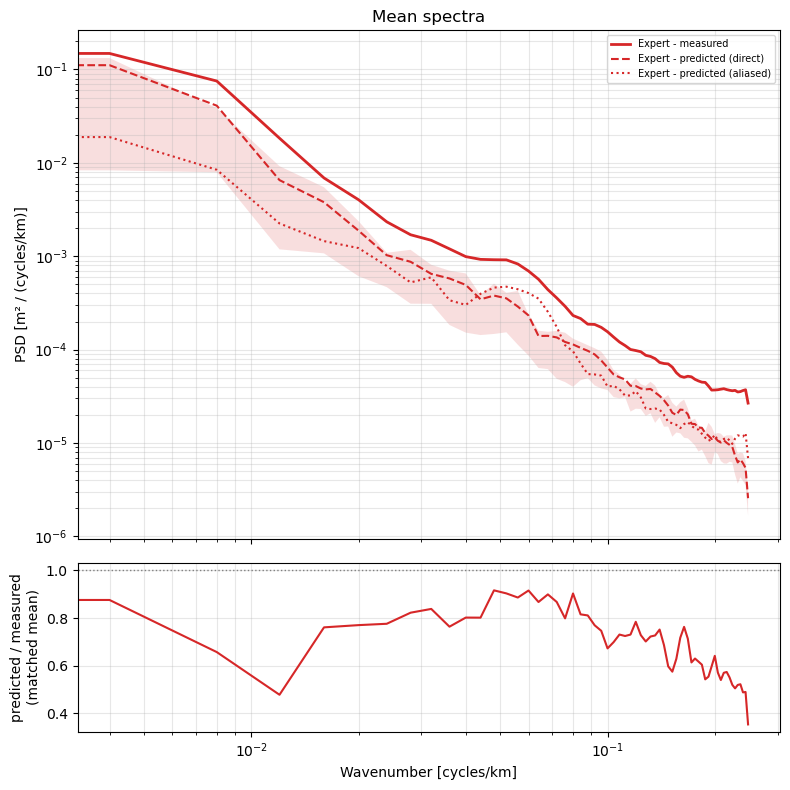

In [218]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
colors = {'left': 'C0', 'right': 'C3'}

k = flagged['wavenumber']
direct_median = flagged.direct_psd.mean('segment')#np.nanmean(direct_stack, axis=0)
direct_lo, direct_hi = np.nanpercentile(flagged.direct_psd, [25, 75], axis=0)
aliased_median = flagged.aliased_psd.mean('segment')
aliased_lo, aliased_hi = np.nanpercentile(flagged.aliased_psd, [25, 75], axis=0)
meas_median = flagged.meas_psd.mean('segment')
total_median = flagged.total_psd.mean('segment')

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
ax.loglog(k, meas_median, c=c, lw=2, label=f'Expert - measured ')
ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')
axs[1].semilogx(k, total_median / meas_median, c=c, lw=1.5)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].set_title(f'Mean spectra')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured\n(matched mean)')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
#axs[1].legend(fontsize=8)
fig.tight_layout(),ax

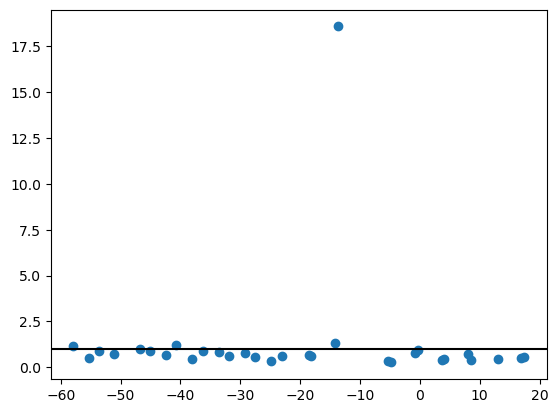

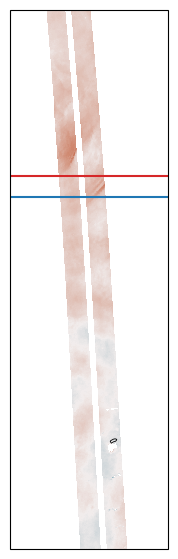

In [239]:

kmin,kmax=1/30,1/10
plt.figure()
_ds = flagged.sel(wavenumber=slice(kmin,kmax))
plt.scatter(_ds.lat_mean,_ds.aliased_psd.integrate('wavenumber') / _ds.direct_psd.integrate('wavenumber'))
plt.axhline(1,c='k')

lat_aliased = [l for l in _ds.where(_ds.aliased_psd.integrate('wavenumber') / _ds.direct_psd.integrate('wavenumber') >1.0, drop=True
                                   ).lat_mean.values]

fig,ax = plt.subplots(figsize=(14,7),subplot_kw={'projection':ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}

sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], data_expert['ssha'], transform=ccrs.PlateCarree(),
                   cmap=cmocean.cm.balance, vmin = -1, vmax=1)
for l in lat_aliased:
    ax.plot([60,65], [l,l], transform=ccrs.PlateCarree())
#ax.plot([60,65], [-17.9,-17.9], transform=ccrs.PlateCarree())

ax.set_extent([61,64,-22,-10], crs=ccrs.PlateCarree())

plt.show()


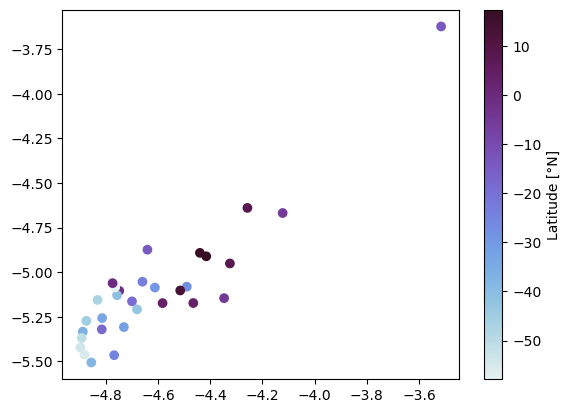

In [240]:
fig, ax = plt.subplots()
_ds = flagged.sel(wavenumber=slice(kmin,kmax))
sc = ax.scatter(np.log10(_ds.meas_psd.integrate('wavenumber')),np.log10(_ds.aliased_psd.integrate('wavenumber')),
           c=_ds.lat_mean,cmap=cmocean.cm.dense)
plt.colorbar(sc,ax=ax,label='Latitude [°N]')
#plt.axhline(1,c='k')

Text(0.5, 1.0, 'Direct, Expert')

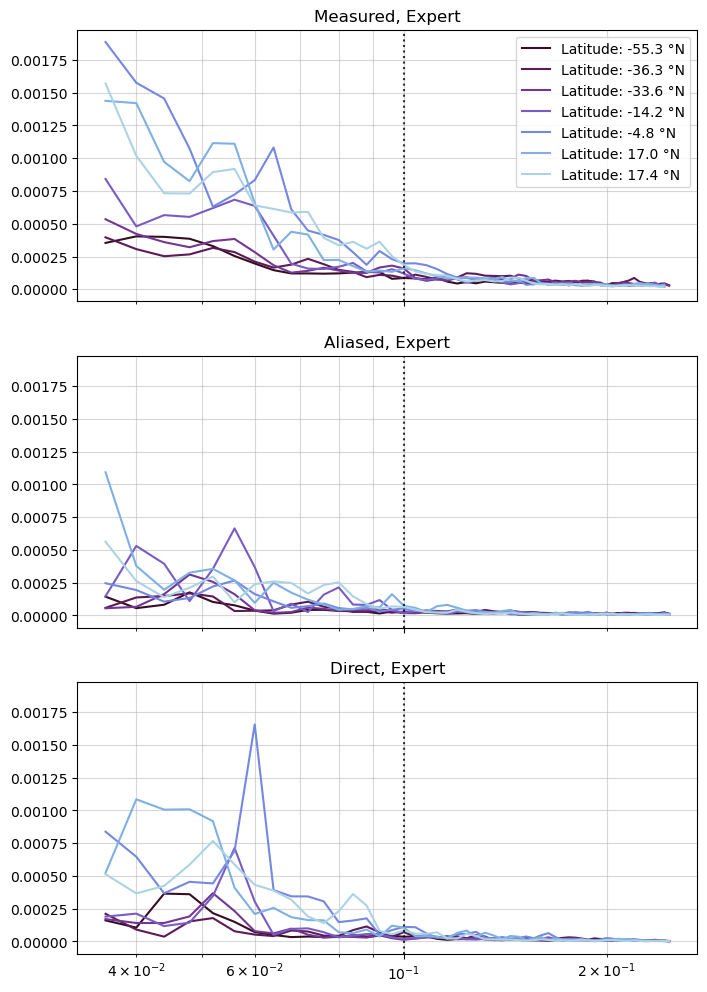

In [241]:
latitudes = np.sort(flagged.lat_mean.dropna('segment')[::5])#np.arange(flagged.lat_mean.min(),flagged.lat_mean.max(),2)
cmap = plt.get_cmap(cmocean.cm.dense_r)
norm = plt.Normalize(vmin=0, vmax=latitudes.size)

fig, axs = plt.subplots(3,1,figsize=(8,12),sharey=True,sharex=True
                       )
for i,l in enumerate(latitudes):
    if flagged.aliased_psd.where(flagged.lat_mean==l,drop=True).size==0:
        pass
    else:
        _ = flagged.where(flagged.lat_mean==l,drop=True).sel(wavenumber=slice(1/30,None))
        axs[0].semilogx(_.wavenumber,(_.meas_psd)[0,:], c=cmap(norm(i)),label=f'Latitude: {l:.1f} °N')
        axs[1].semilogx(_.wavenumber,(_.aliased_psd)[0,:], c=cmap(norm(i)))
        axs[2].semilogx(_.wavenumber,(_.direct_psd)[0,:], c=cmap(norm(i)))
for ax in axs:
    ax.grid(True,which='both',alpha=0.5)
    #ax.axvline(1/30,ls=':',c='k',alpha=0.8)
    #ax.axvline(1/50,ls=':',c='k',alpha=0.8)
    ax.axvline(1/10,ls=':',c='k',alpha=0.8)
axs[0].legend()
axs[0].set_title('Measured, Expert');
axs[1].set_title('Aliased, Expert');
axs[2].set_title('Direct, Expert')

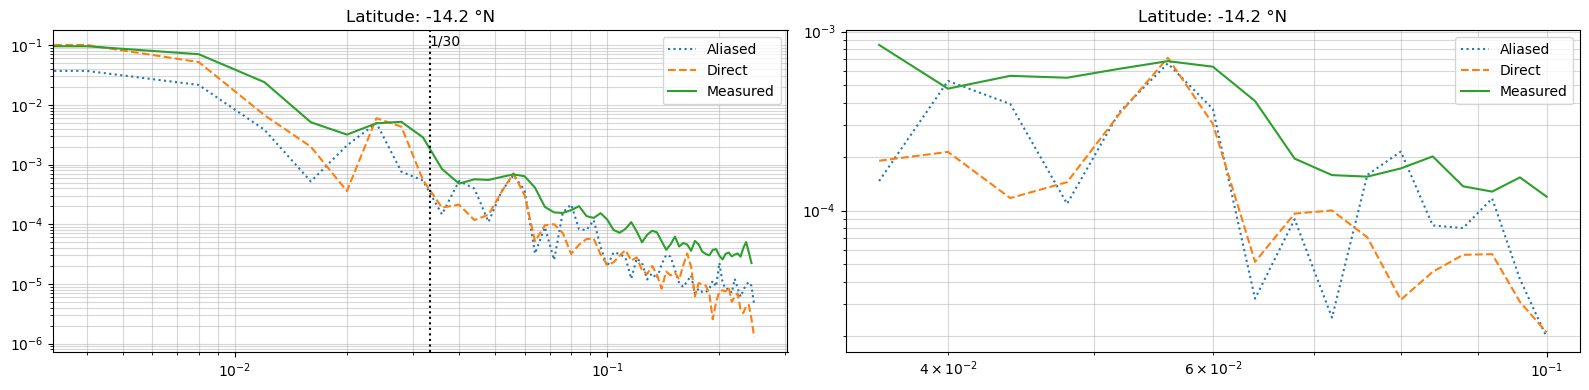

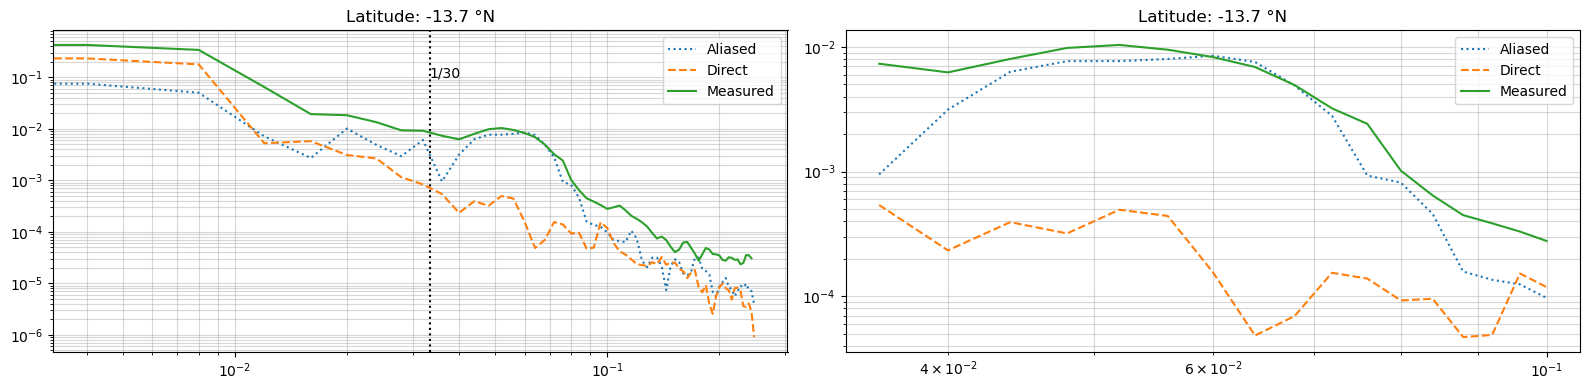

In [267]:
for l in lat_aliased:
    if l>=-22 and l<=8:
        ds_lat = flagged.where(_ds.lat_mean==l,drop=True)
        fig, axs = plt.subplots(1,2,figsize=(16,4),sharey=False)
        ax=axs[0]
        ax.loglog(ds_lat.wavenumber, ds_lat.aliased_psd[0,:],ls=':',label='Aliased')
        ax.loglog(ds_lat.wavenumber, ds_lat.direct_psd[0,:],ls='--',label='Direct')
        ax.loglog(ds_lat.wavenumber, ds_lat.meas_psd[0,:],ls='-',label='Measured')
        ax.axvline(1/30,ls=':',c='k');
        ax.text(1/30,1e-1,'1/30')
        ax=axs[1]
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,kmax)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,kmax)).aliased_psd[0,:]
                  ,ls=':',label='Aliased')
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,kmax)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,kmax)).direct_psd[0,:]
                  ,ls='--',label='Direct')
        ax.loglog(ds_lat.sel(wavenumber=slice(kmin,kmax)).wavenumber, ds_lat.sel(wavenumber=slice(kmin,kmax)).meas_psd[0,:]
                  ,ls='-',label='Measured')
        for ax in axs:
            ax.legend();ax.grid(True,which='both',alpha=0.5)
            ax.set_title(f'Latitude: {l:.1f} °N');
        fig.tight_layout()